In [45]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Read annotation file

In [46]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [47]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data")
paths = os.listdir(path_to_results)

In [48]:
cell_types = ["CD14-Mono",
              "CyclingProgenitor*",
              "DCs-CD14",
              "Early_Pro-B", 
              "EosBasoMastPre", 
              "EryPro",
              "GMP-Neutro:CD16-Mono",
              "HSCs",
              "MgkPro",
              "Pro-B"]

In [49]:
pure_cell_type_solution_dict = {cell_type: [] 
                                for cell_type in cell_types
                               }

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            config_exp_folders = cell_type_file_paths / cell_type
            # For all the experiments in the folders 
            for config_exp_folder in os.listdir(config_exp_folders):
                # Be sure candidates are there 
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    uncertainty_path = config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv"
                    # Be sure uncertainty annotation exists 
                    if uncertainty_path.exists():
                        candidate_with_uncertainty_df = pd.read_csv(uncertainty_path)
                        candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                        pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 18/18 [03:19<00:00, 11.06s/it]


In [68]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [69]:
for col in pure_cell_type_solution_dict_concat["HSCs"].columns:
    print(col)

Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14-Mono_prop
CD49c-Myeloid_prop
CyclingProgenitor*_prop
DCs-CD14_prop
EarlyGMP_prop
Early_Pro-B_prop
EosBasoMastPre_prop
EosBasoMastPre_2_prop
EryPro_prop
GMP-Cycle_prop
GMP-Neutro_prop
GMP-Neutro/CD16-Mono_prop
HSCs_prop
MEP_prop
MLP_prop
MPP_prop
MgkPro_prop
Pro-B_prop
pDCs/cDCs_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_rep
cfg:annotation:scatter_obsm_key
cfg:annotat

### Initialize targets

In [70]:
# Cell type fractions
celltype_fraction = {
    "MgkPro": 0.15,
    "HSCs": 0.15,
    "EryPro": 0.15,
    "GMP-Neutro/CD16-Mono": 0.15,
    "CyclingProgenitor*": 0.15,
    "EosBasoMastPre": 0.15,
    "Early_Pro-B": 0.15,
    "Pro-B": 0.15,
    "CD14-Mono": 0.15,
    "DCs-CD14": 0.15
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
    "exploitation_score",
    "exploration_score",
    "weighted_uncertainty_score",
    "metric_response_surface"
]

### Filter values

In [71]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [72]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered CD14-Mono number of solutions: 14783
Unfiltered CD14-Mono number of solutions: 43000 

Filtered CyclingProgenitor* number of solutions: 9554
Unfiltered CyclingProgenitor* number of solutions: 37900 

Filtered DCs-CD14 number of solutions: 2157
Unfiltered DCs-CD14 number of solutions: 43100 

Filtered Early_Pro-B number of solutions: 97
Unfiltered Early_Pro-B number of solutions: 48100 

Filtered EosBasoMastPre number of solutions: 8769
Unfiltered EosBasoMastPre number of solutions: 48100 

Filtered EryPro number of solutions: 4275
Unfiltered EryPro number of solutions: 43100 

Filtered GMP-Neutro:CD16-Mono number of solutions: 7622
Unfiltered GMP-Neutro:CD16-Mono number of solutions: 30400 

Filtered HSCs number of solutions: 57
Unfiltered HSCs number of solutions: 33100 

Filtered MgkPro number of solutions: 1219
Unfiltered MgkPro number of solutions: 65600 

Filtered Pro-B number of solutions: 22
Unfiltered Pro-B number of solutions: 38100 



## Plot cell type proportions vs value of the parameter 

Filtered 

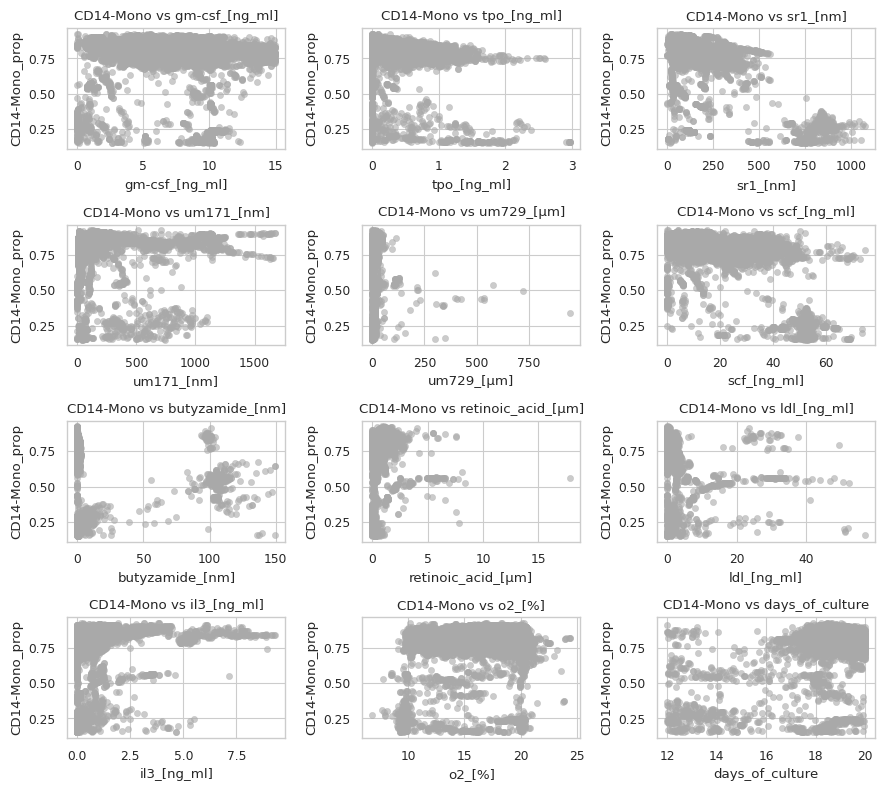

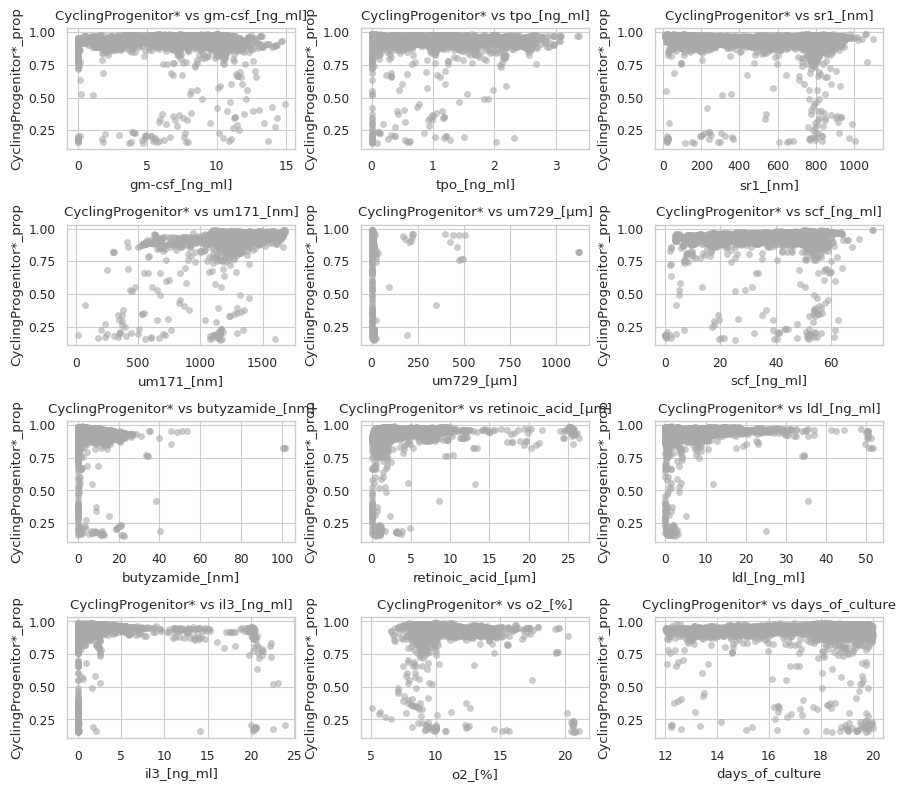

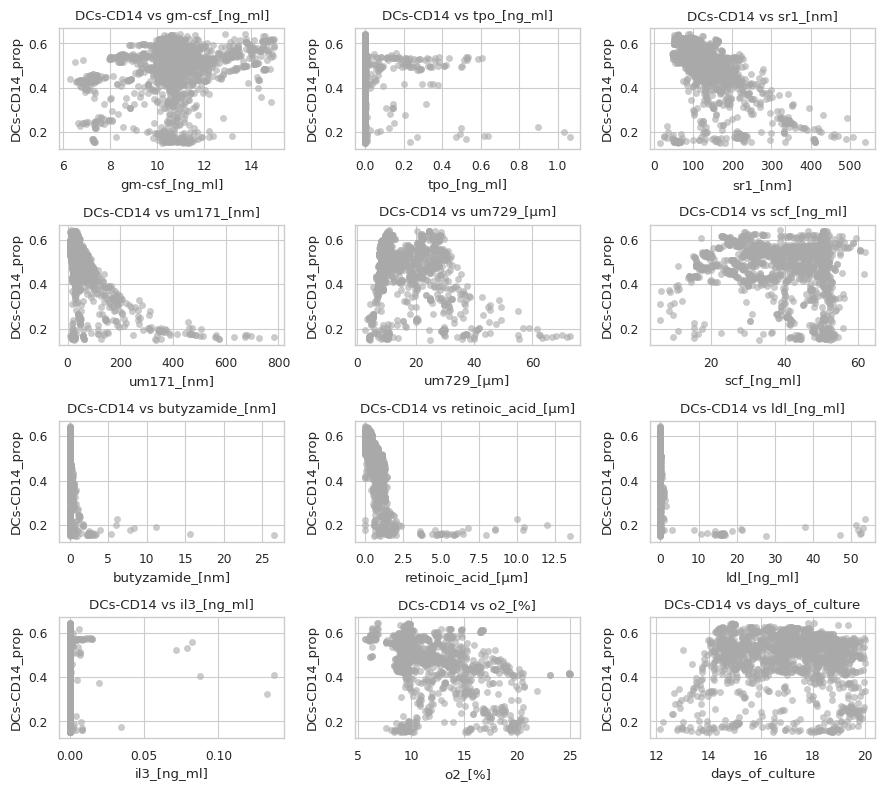

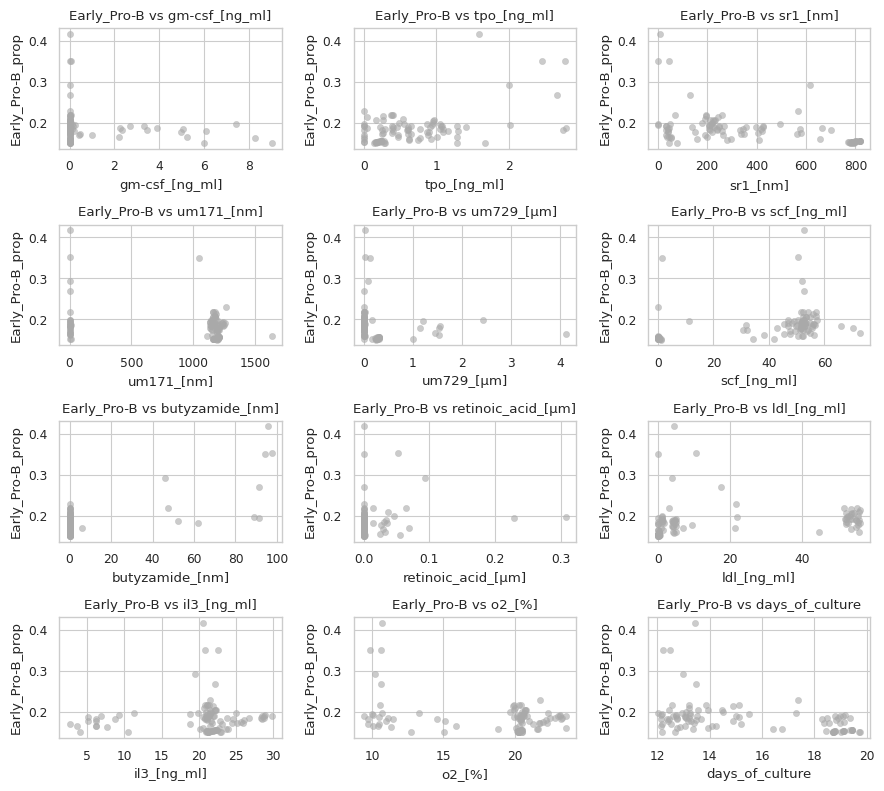

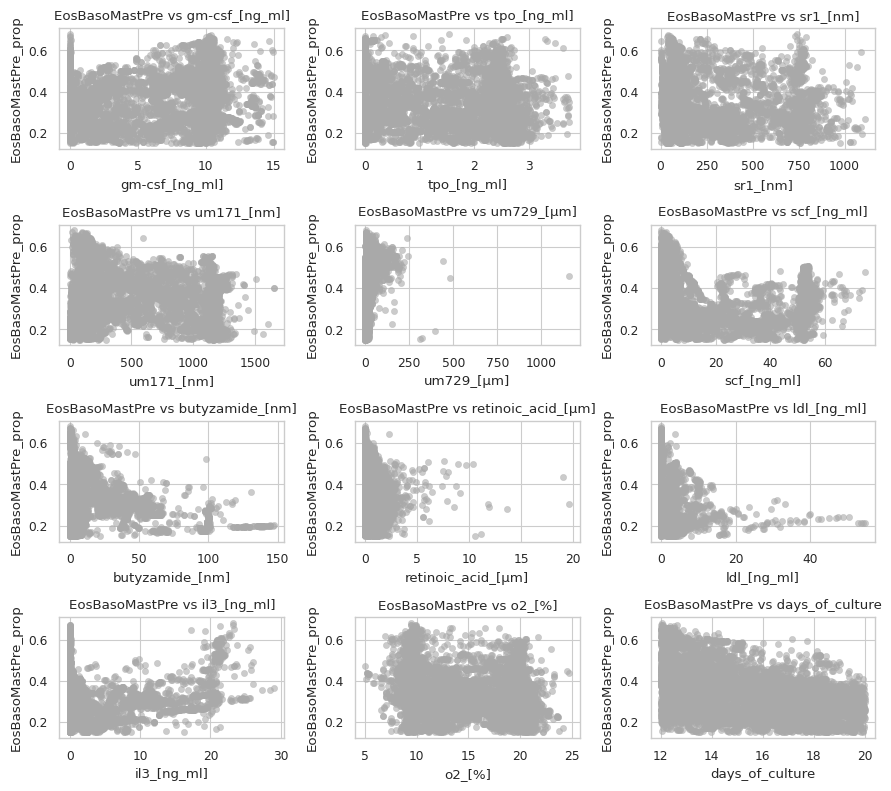

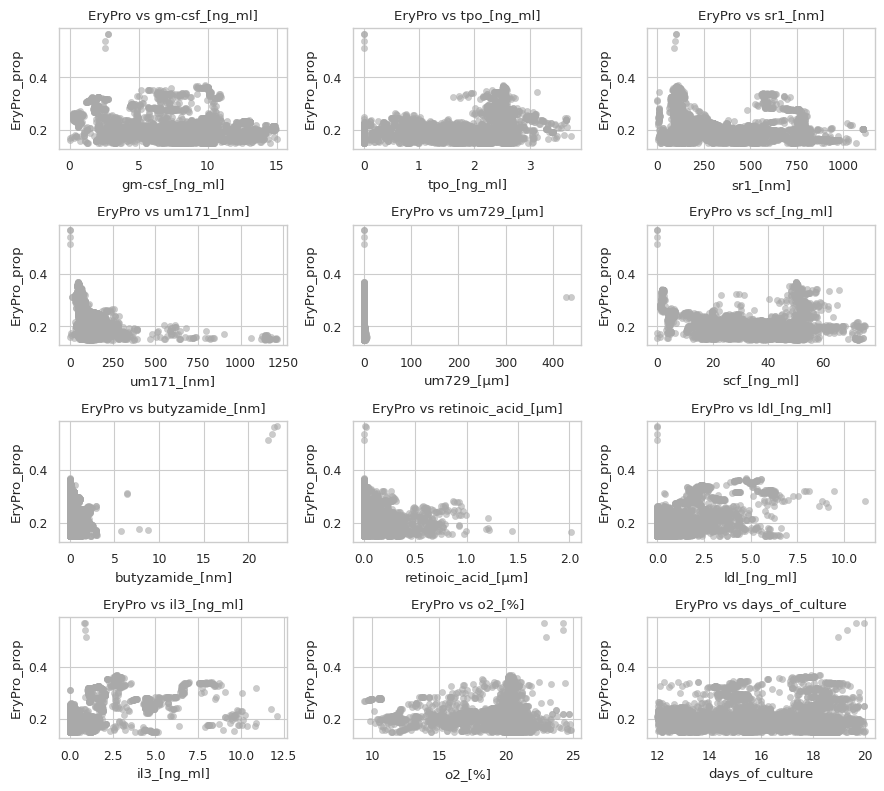

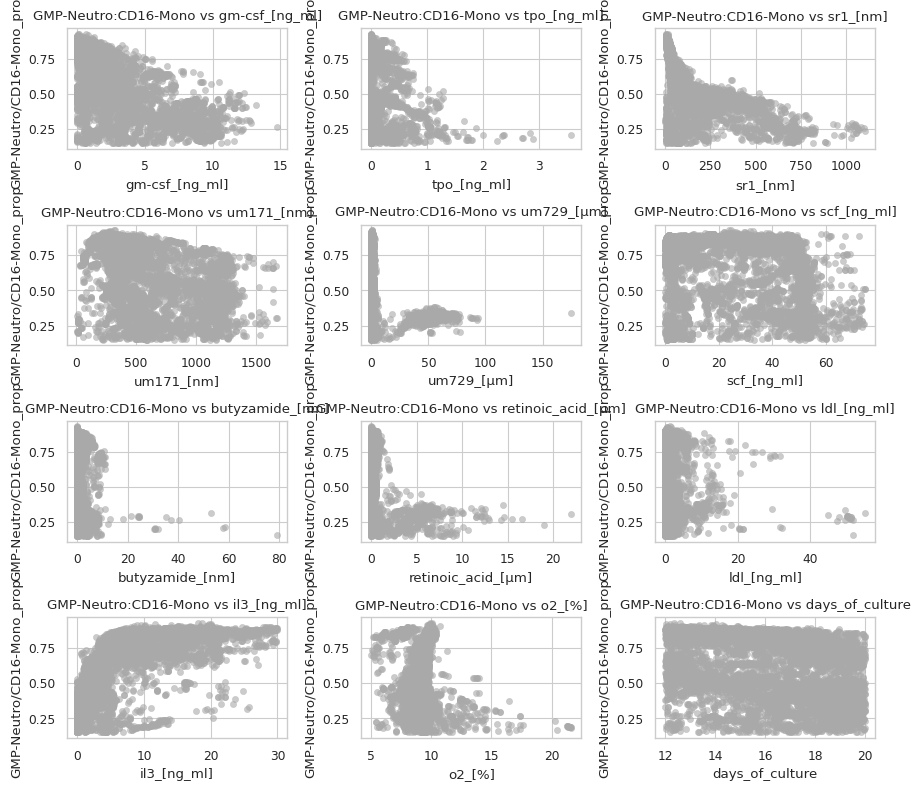

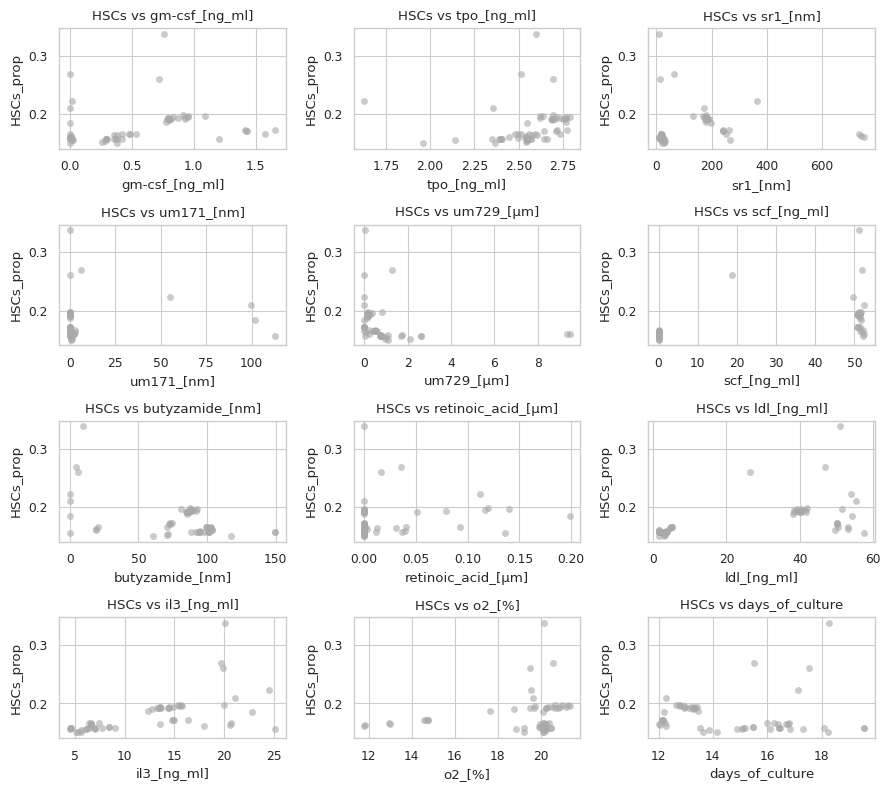

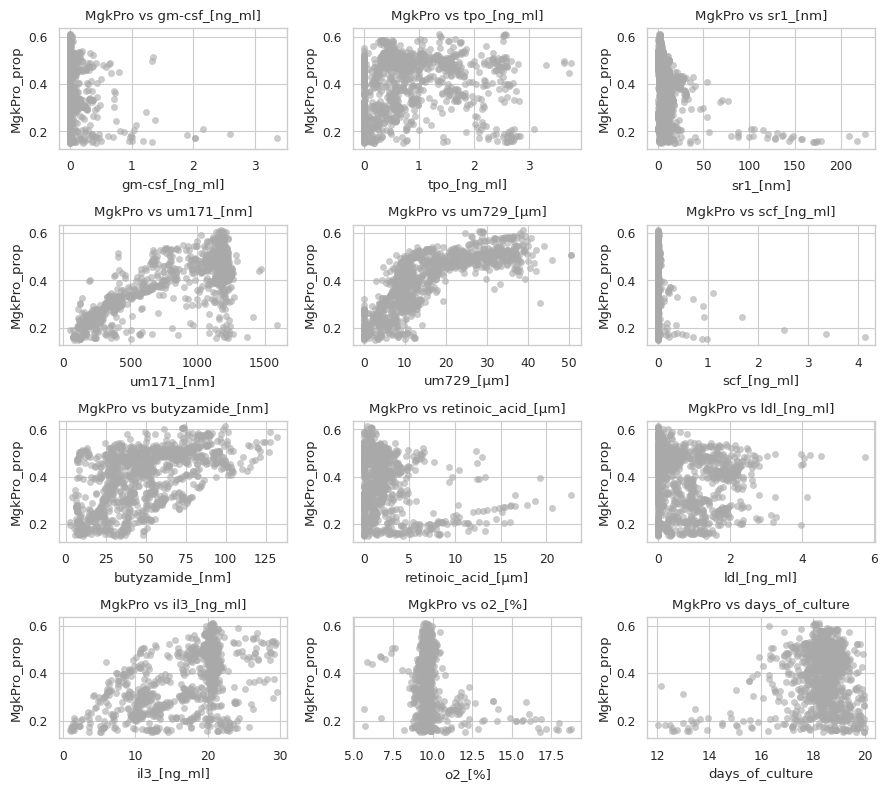

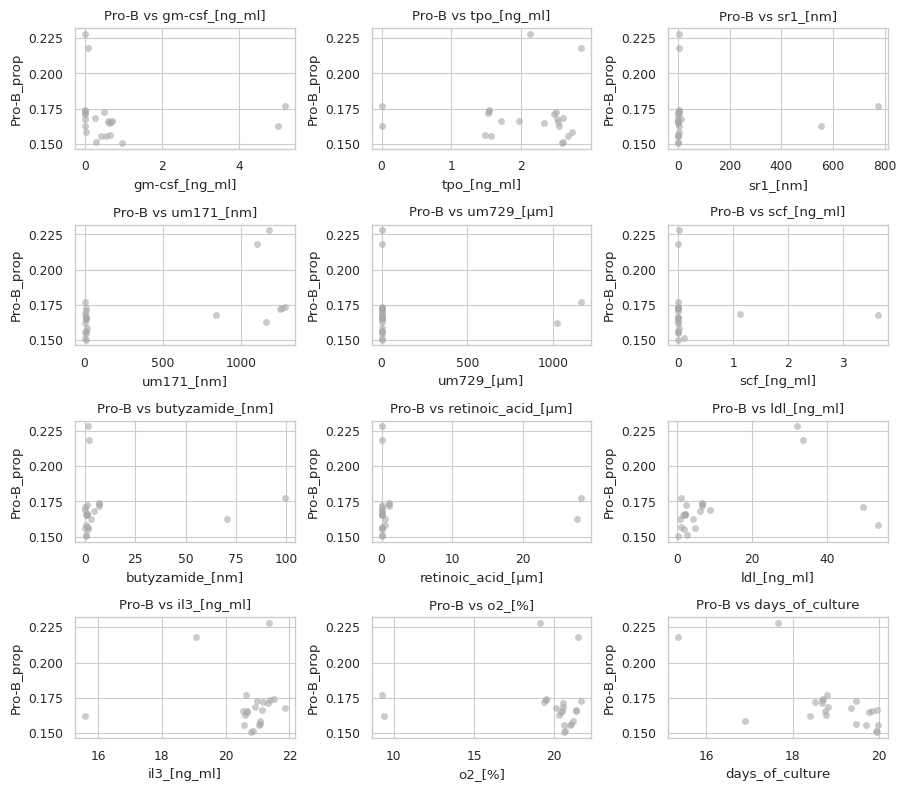

In [73]:
for cell_type in filtered_df:
    # Cell type safe
    cell_type_safe = cell_type.replace(":", "/")
    
    n_params = len(protocol_cols)
    ncols = 3  # adjust as you like
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    fig.subplots_adjust(
        hspace=0.9,   
        wspace=0.6    
    )
    axes = axes.flatten()  # make indexing easy

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=filtered_df[cell_type],
            x=param,
            y=f"{cell_type_safe}_prop",
            ax=axes[i], 
            s=20,
            alpha=0.6,
            edgecolor=None, 
            color="darkgrey"
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

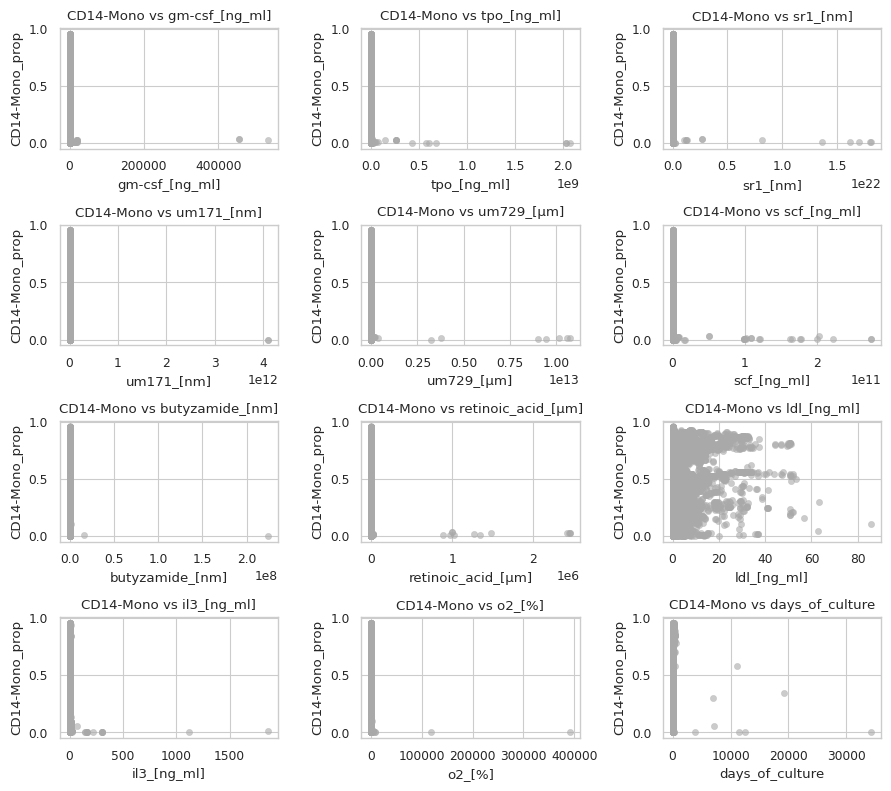

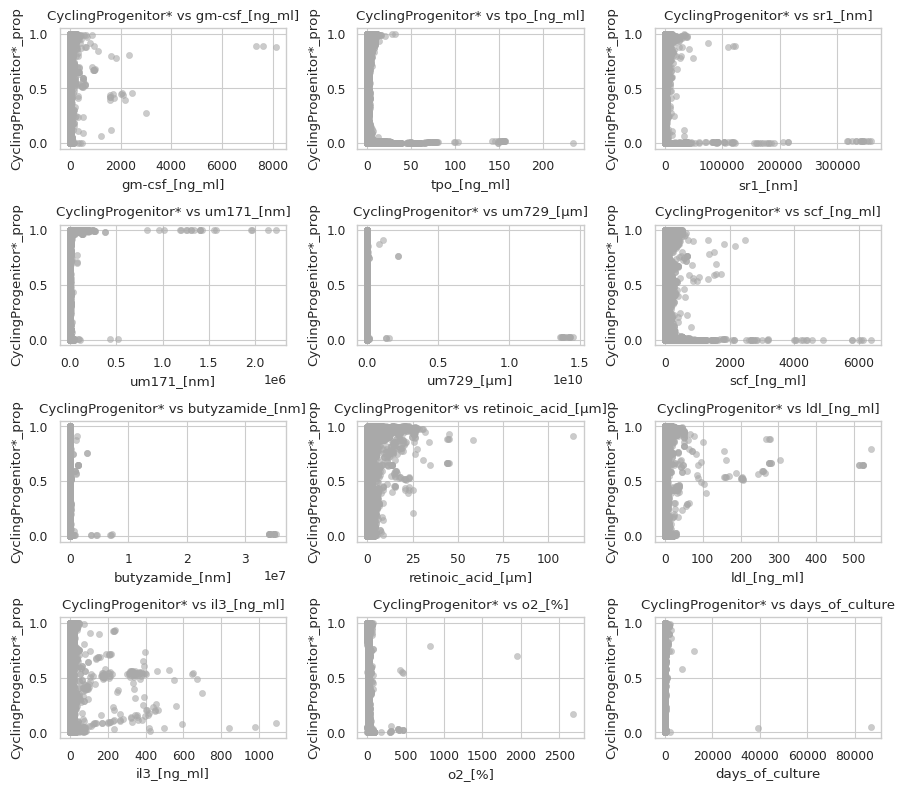

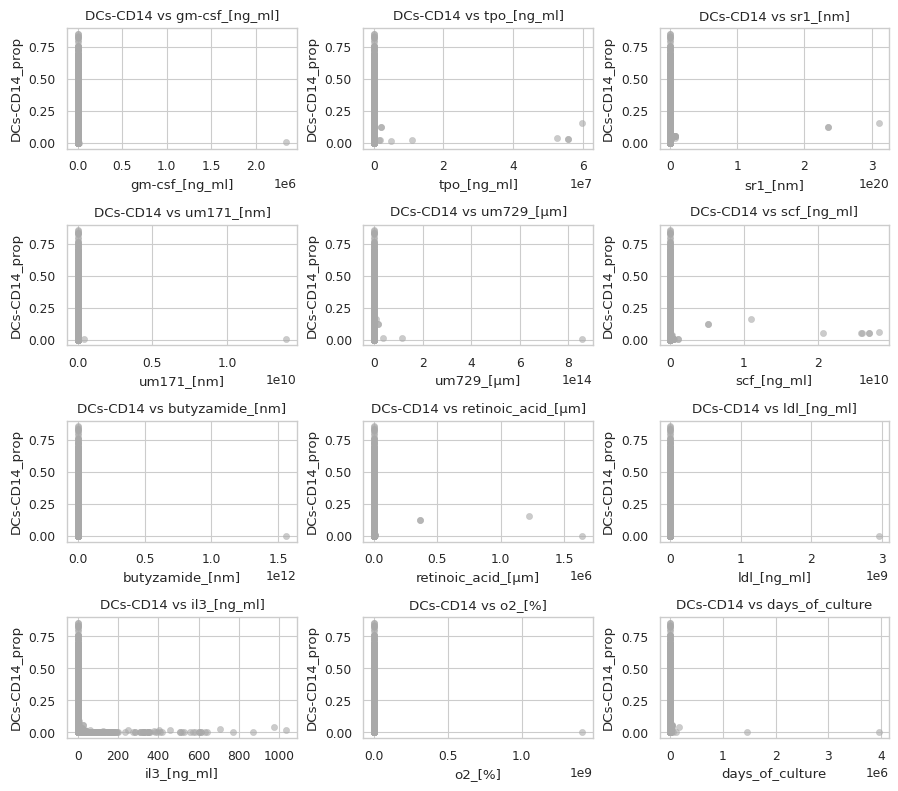

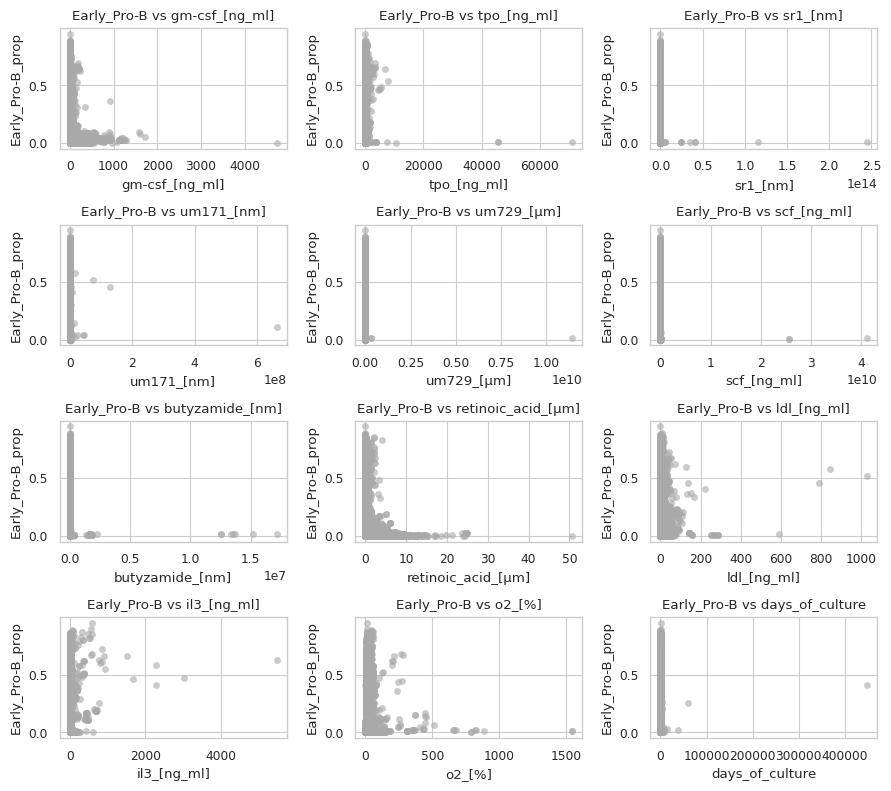

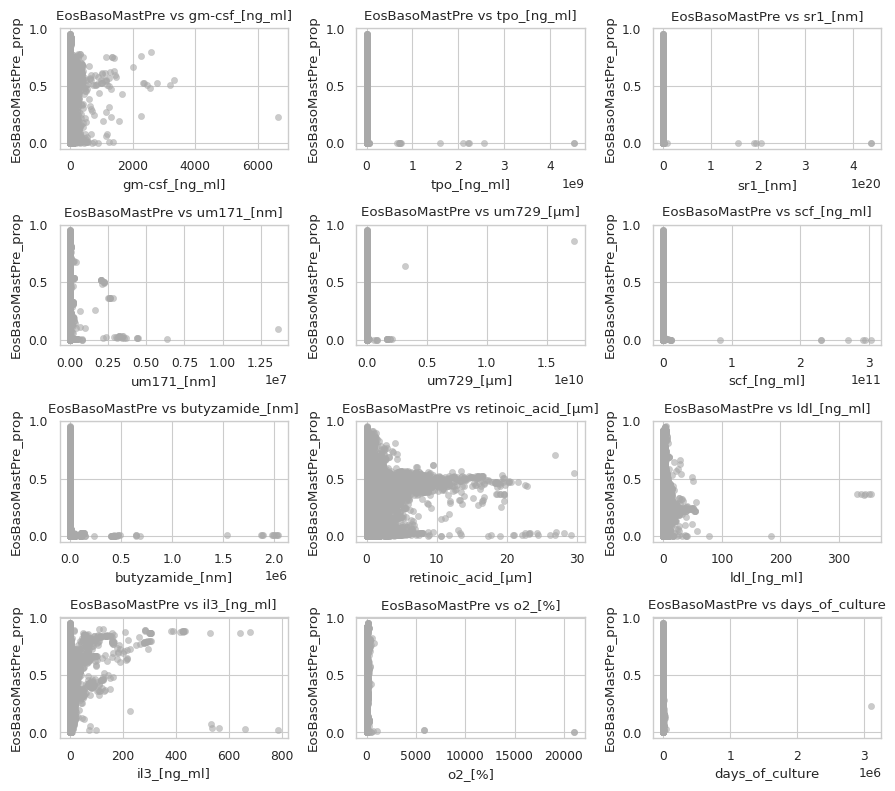

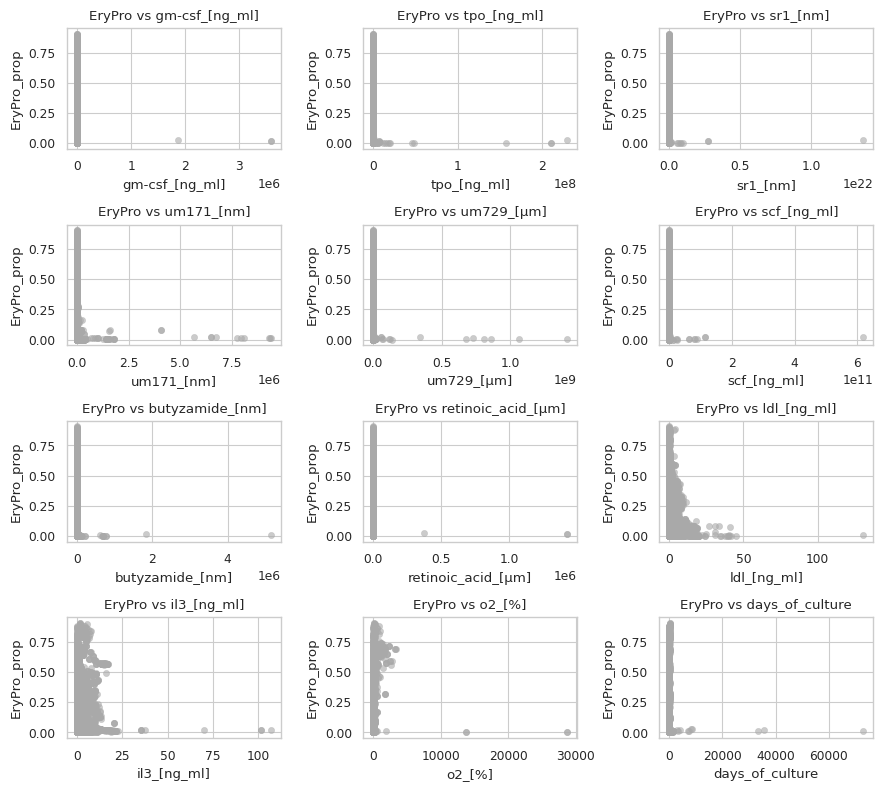

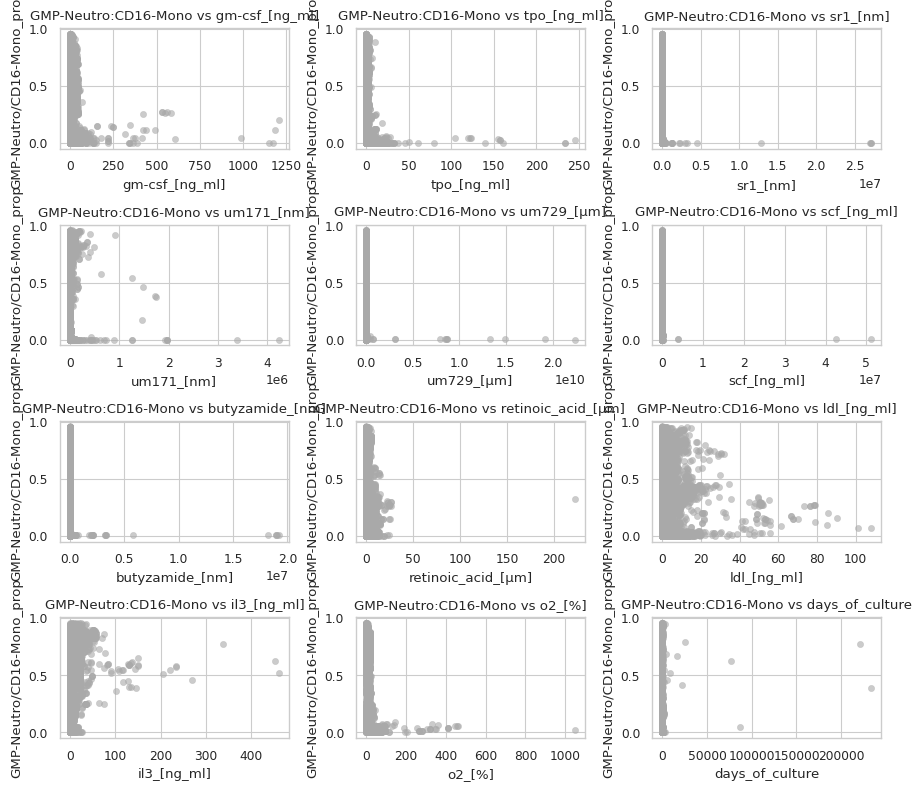

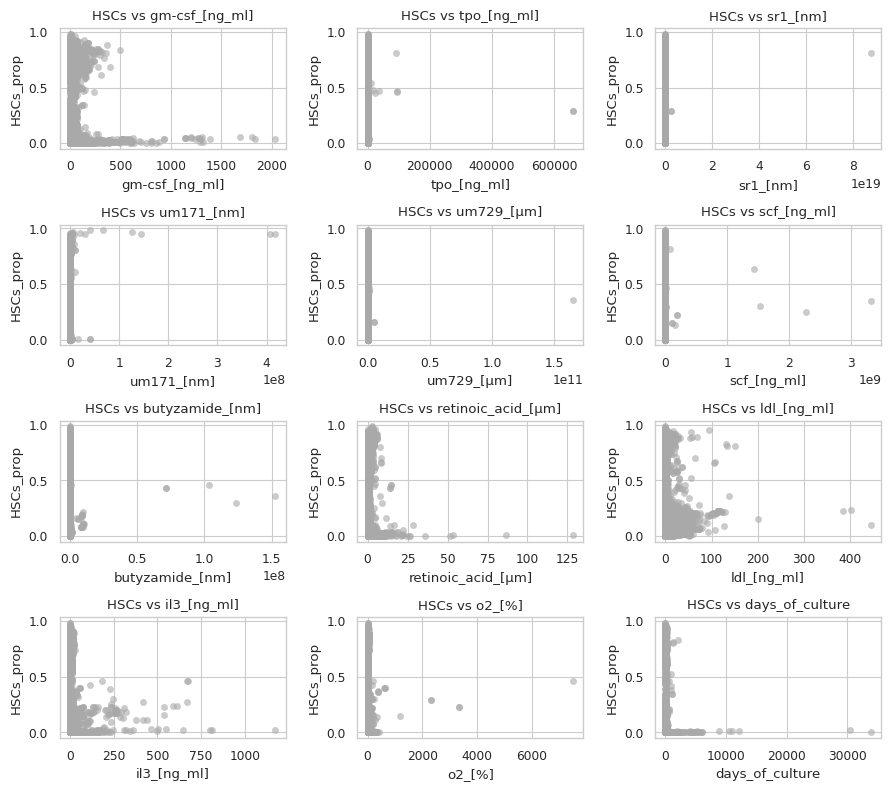

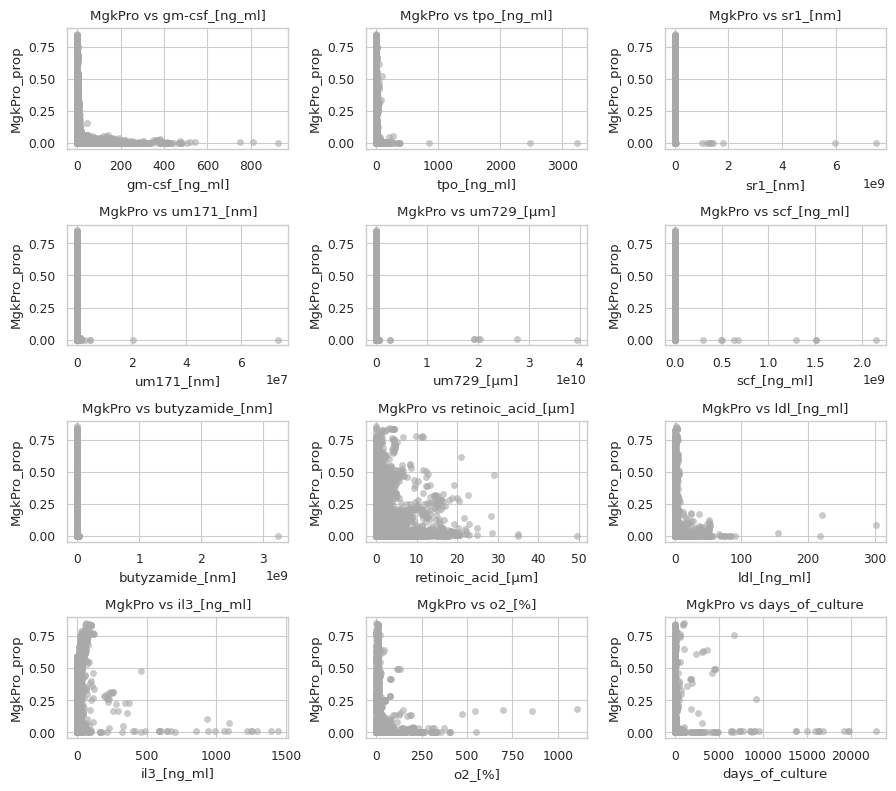

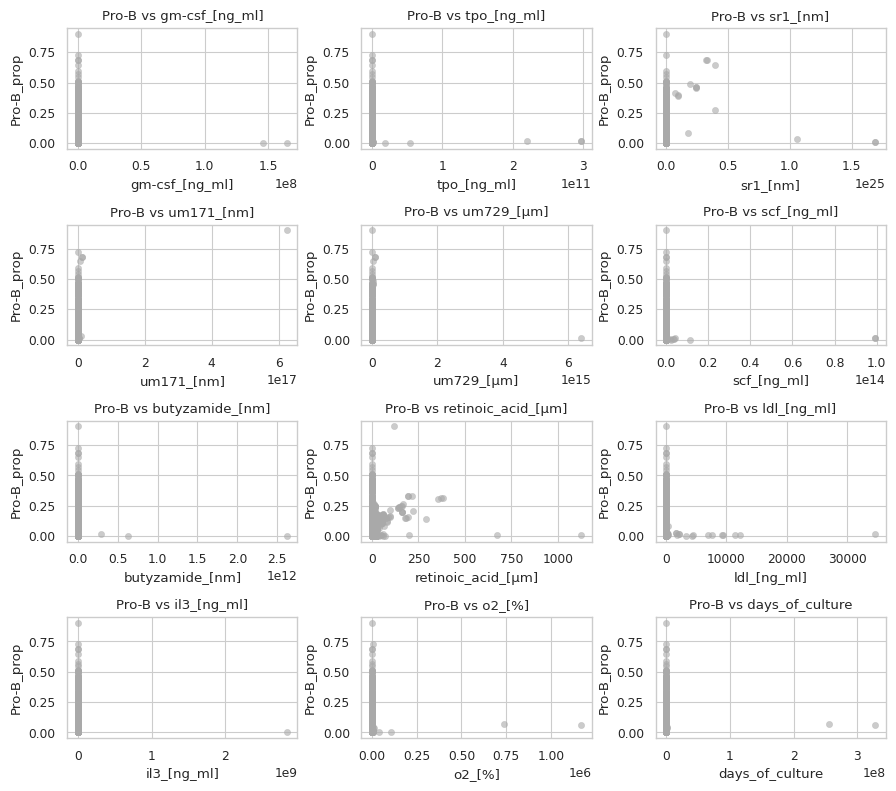

In [74]:
for cell_type in pure_cell_type_solution_dict_concat:
    # Cell type safe
    cell_type_safe = cell_type.replace(":", "/")
    
    n_params = len(protocol_cols)
    ncols = 3  # adjust as you like
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    fig.subplots_adjust(
        hspace=0.9,   
        wspace=0.6    
    )
    axes = axes.flatten()  # make indexing easy

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=pure_cell_type_solution_dict_concat[cell_type].reset_index(),
            x=param,
            y=f"{cell_type_safe}_prop",
            ax=axes[i], 
            s=20,
            alpha=0.6,
            edgecolor=None, 
            color="darkgrey"
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## Check the calibration (loss vs loss_std)

Loss vs. cell type proportion

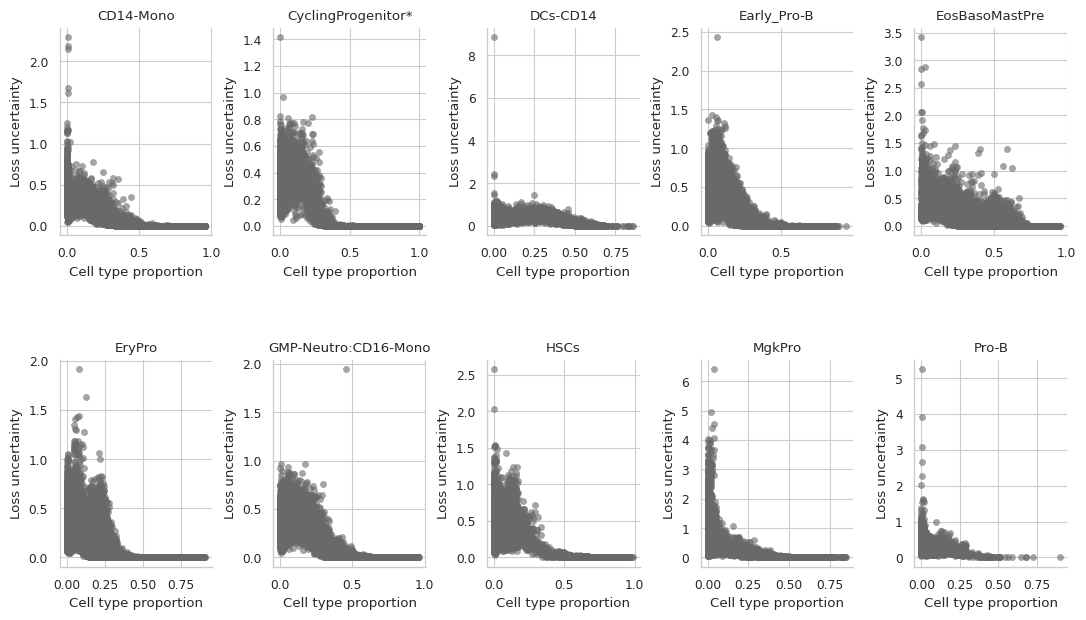

In [75]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

axes = axes.flatten()

for i, cell_type in enumerate(pure_cell_type_solution_dict_concat):

    cell_type_safe = cell_type.replace(":", "/")
    df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        y="target_ct_loss_std",
        color="dimgray",
        legend=False,
        ax=ax,
        s=20,
        alpha=0.6,
        edgecolor=None
    )

    ax.set_title(cell_type)
    ax.set_xlabel("Cell type proportion")
    ax.set_ylabel("Loss uncertainty")

    sns.despine(ax=ax)

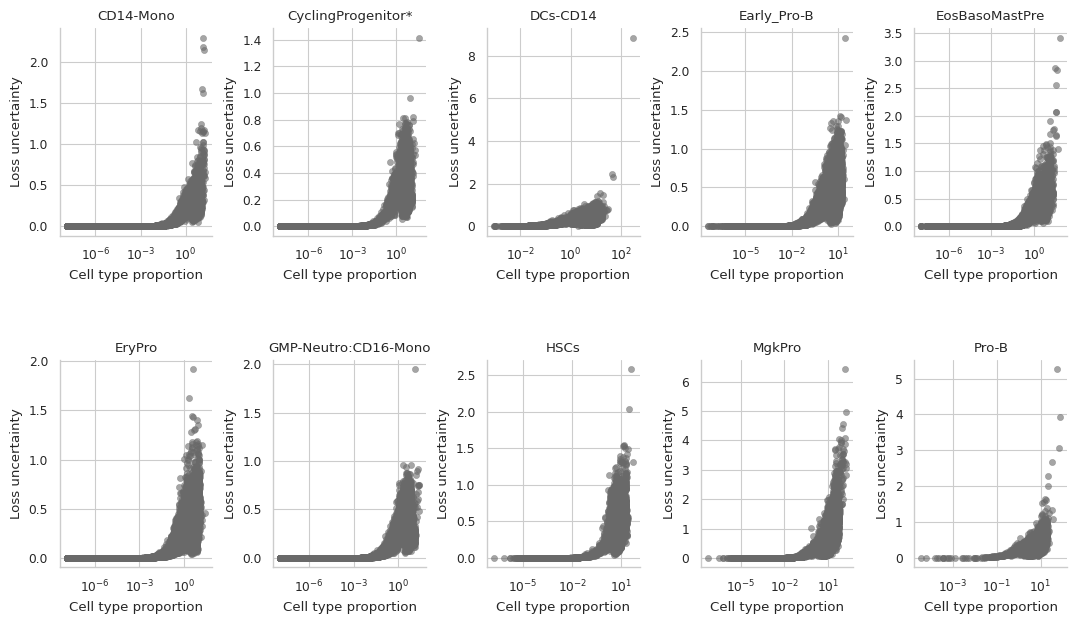

In [76]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

axes = axes.flatten()

for i, cell_type in enumerate(pure_cell_type_solution_dict_concat):

    cell_type_safe = cell_type.replace(":", "/")
    df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x="target_ct_loss_mean",
        y="target_ct_loss_std",
        color="dimgray",
        legend=False,
        ax=ax,
        s=20,
        alpha=0.6,
        edgecolor=None
    )

    ax.set_title(cell_type)
    ax.set_xlabel("Cell type proportion")
    ax.set_xscale('log')
    ax.set_ylabel("Loss uncertainty")

    sns.despine(ax=ax)

The uncertainty is well calibrated 

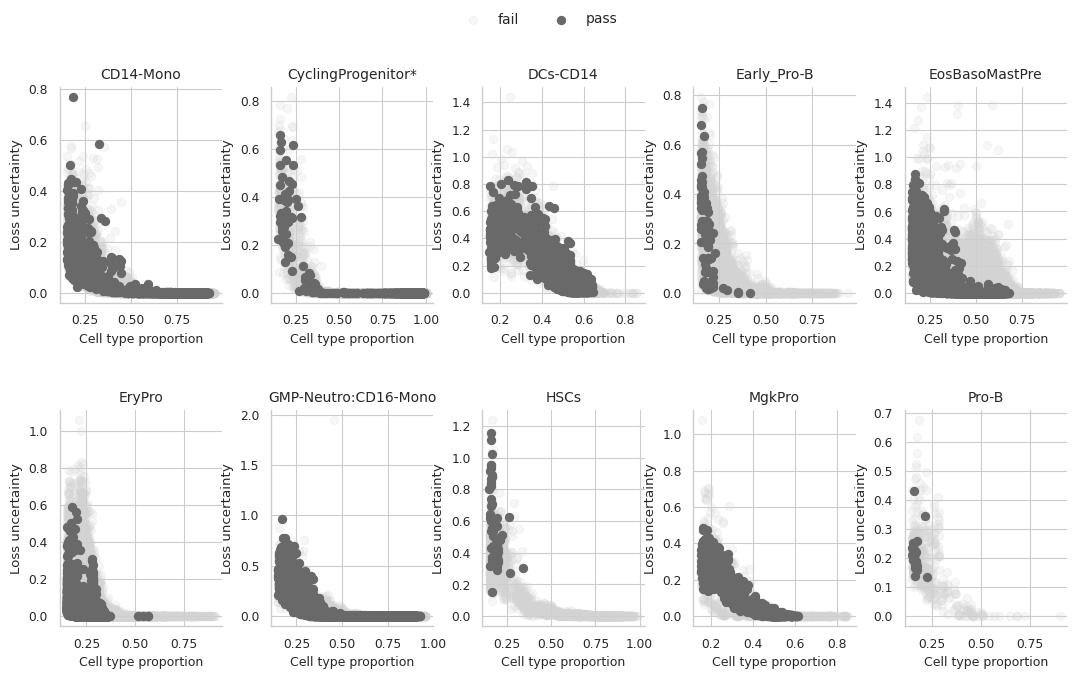

In [77]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
axes = axes.flatten()

for i, cell_type in enumerate(annotated_df):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = annotated_df[cell_type].reset_index(drop=True)
    df_plot["pass_filter"] = (df_plot["filtering_step"] == "pass")

    ax = axes[i]

    # Map True/False to colors
    color_map = {True: "dimgray", False: "lightgray"}
    alpha_map = {True: 1, False: 0.2}  # more transparent for False points

    for val in [False, True]:
        subset = df_plot[df_plot["pass_filter"] == val]
        ax.scatter(
            subset[f"{cell_type_safe}_prop"],
            subset["target_ct_loss_std"],
            color=color_map[val],
            alpha=alpha_map[val],
            s=35,
            edgecolor=None,
            label=str(val)
        )

    ax.set_title(cell_type, fontsize=10)
    ax.set_xlabel("Cell type proportion", fontsize=9)
    ax.set_ylabel("Loss uncertainty")
    sns.despine(ax=ax)

# Add a single legend for the figure
fig.legend(
    ["fail", "pass"],  # nicer labels
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10
)

plt.show()

/tmp/ipykernel_717353/4223443147.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_717353/4223443147.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_717353/4223443147.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_717353/4223443147.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_717353/4223443147.py:16: FutureWa

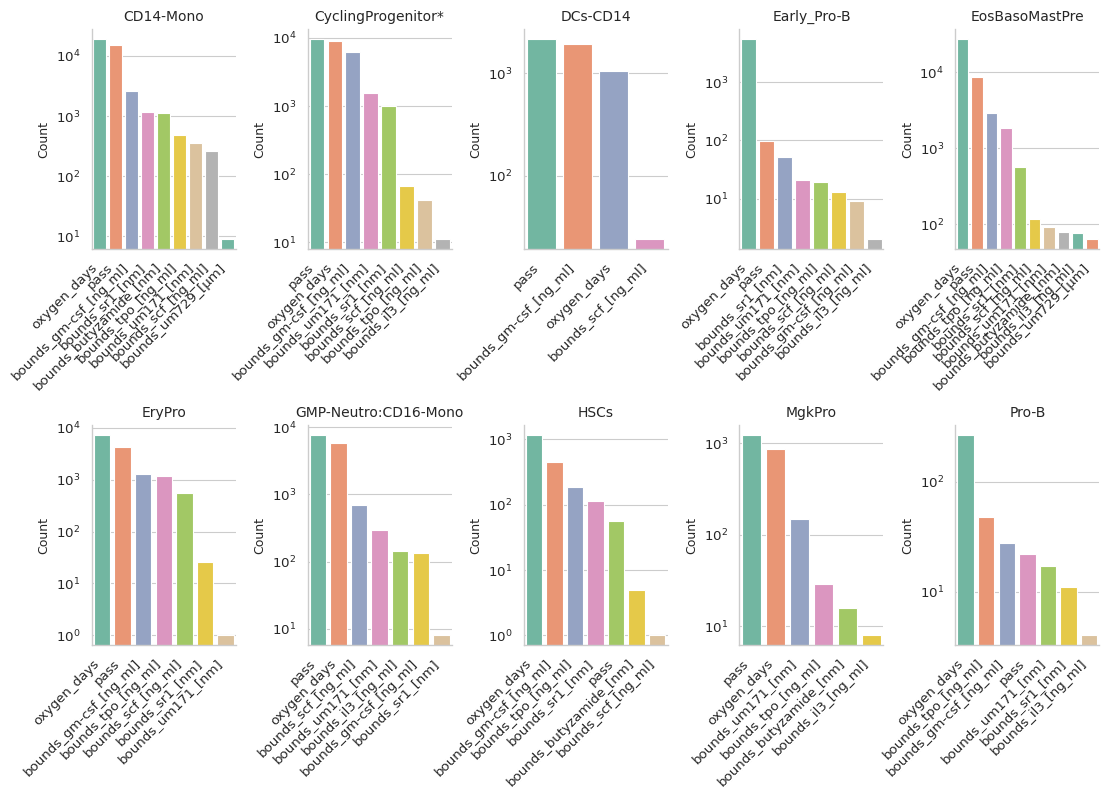

In [78]:
sns.set(style="whitegrid", context="paper", font_scale=1.1)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 8))
fig.subplots_adjust(hspace=0.8, wspace=0.5)
axes = axes.flatten()

for i, cell_type in enumerate(annotated_df):
    df_plot = annotated_df[cell_type].reset_index(drop=True)
    ax = axes[i]

    # Compute counts for sorting
    counts = df_plot["filtering_step"].value_counts()
    sorted_categories = counts.index.tolist()  # ordered by count descending

    # Count plot ordered by height
    sns.countplot(
        data=df_plot,
        x="filtering_step",
        order=sorted_categories,
        ax=ax, 
        palette="Set2"
    )

    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yscale("log")  # log scale
    ax.set_title(cell_type, fontsize=10)
    ax.set_xlabel("")  # optional: remove repeated x-labels
    ax.set_ylabel("Count", fontsize=9)
    sns.despine(ax=ax)

# Remove empty subplots if fewer than 10
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

## Rearrange solutions' columns 

In [79]:
for cell_type in filtered_df:
    # Clean filtered data frames 
    filtered_df[cell_type]= filtered_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    filtered_df[cell_type] = filtered_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

    # Clean unfiltered dataframes 
    annotated_df[cell_type]= annotated_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    annotated_df[cell_type] = annotated_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

## Subsample by uncertainty 

In [80]:
filtered_df_subsample = {}

for cell_type in filtered_df:
    if filtered_df[cell_type].shape[0] > 200:
        filtered_df_subsample_ct = []
        sorted_df_uncertainty = filtered_df[cell_type].sort_values(by="uncertainty_loss", ascending=True)
        filtered_df_subsample_ct.append(sorted_df_uncertainty[:100])
        filtered_df_subsample_ct.append(sorted_df_uncertainty[-100:])
        filtered_df_subsample_ct = pd.concat(filtered_df_subsample_ct, axis=0)
        filtered_df_subsample[cell_type] = filtered_df_subsample_ct
    else:
        filtered_df_subsample[cell_type] = filtered_df[cell_type]

for cell_type in filtered_df_subsample:
    print(cell_type)
    print(filtered_df_subsample[cell_type].shape)

CD14-Mono
(200, 23)
CyclingProgenitor*
(200, 23)
DCs-CD14
(200, 23)
Early_Pro-B
(97, 23)
EosBasoMastPre
(200, 23)
EryPro
(200, 23)
GMP-Neutro:CD16-Mono
(200, 23)
HSCs
(57, 23)
MgkPro
(200, 23)
Pro-B
(22, 23)


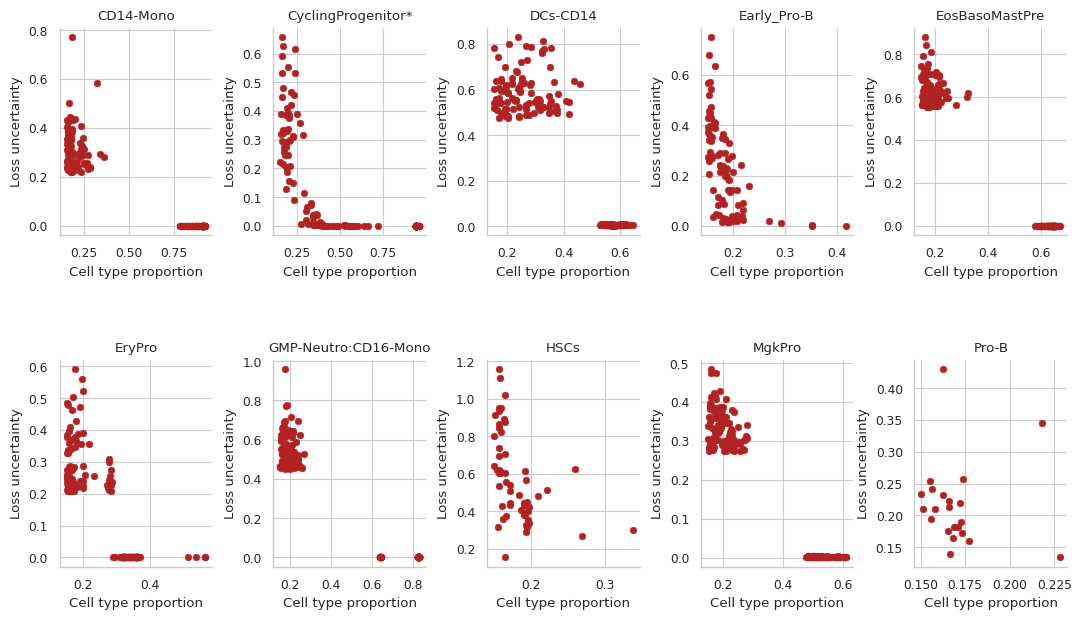

In [100]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(filtered_df_subsample):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = filtered_df_subsample[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        y="uncertainty_loss",
        ax=ax,
        edgecolor=None, 
        color="firebrick", 
    )

    # ax.set_yscale("log")   
    ax.set_title(cell_type)
    ax.set_xlabel("Cell type proportion")
    ax.set_ylabel("Loss uncertainty")
    sns.despine(ax=ax)

Alternative approach: cluster and reduce number of solutions. 

In [82]:
# np.random.seed(42)

# filtered_df_subsampled = {}
# annotated_df_subsampled = {}

# n_samples_filtered = 100
# n_samples_unfiltered = 100

# def fps_subsample(df, cols, n):
#     if df.shape[0] <= n:
#         return df

#     X = df[cols].values
#     sampled_ids = fpsample.fps_sampling(X, n)
#     return df.iloc[sampled_ids]

# for cell_type in tqdm(filtered_df):

#     filtered_df_subsampled[cell_type] = fps_subsample(
#         filtered_df[cell_type],
#         protocol_cols,
#         n_samples_filtered
#     )

#     annotated_df_subsampled[cell_type] = fps_subsample(
#         annotated_df[cell_type],
#         protocol_cols,
#         n_samples_unfiltered
#     )

## Save results

In [101]:
# RESULT_PATH = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original")
# RESULT_PATH_FILTERED = RESULT_PATH / "filtered"
# RESULT_PATH_FILTERED.mkdir(exist_ok=True, parents=True)
# RESULT_PATH_ANNOTATED = RESULT_PATH / "annotated"
# RESULT_PATH_ANNOTATED.mkdir(exist_ok=True, parents=True)

# # Save results 
# for cell_type in filtered_df_subsample:
#     filtered_df_subsample[cell_type].to_csv(RESULT_PATH / "filtered" / f"filtered_candidates_{cell_type}.csv")
#     annotated_df[cell_type].to_csv(RESULT_PATH / "annotated" / f"annotated_candidates_{cell_type}.csv")

In [102]:
# import pickle as pkl 

# with open(RESULT_PATH / "fitlered_populations.pkl", "wb") as file:
#     pkl.dump(filtered_df, file)

## Check if uncertainty is connected to rarity

In [103]:
# Read the annotated dataset
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad")

ct_proportions = adata.obs.cell_type.value_counts() /  adata.shape[0]
annotated_df_concat = annotated_df.copy()

for cell_type in annotated_df_concat:
    cell_type_safe = cell_type.replace(":", "/")
    annotated_df_concat[cell_type]["real_ct_prop"] = ct_proportions[cell_type_safe]
    annotated_df_concat[cell_type]["ct"] = cell_type

In [104]:
annotated_df_concat = pd.concat(list(annotated_df_concat.values()), axis=0)
annotated_df_concat = annotated_df_concat.reset_index()

/tmp/ipykernel_717353/4110216269.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


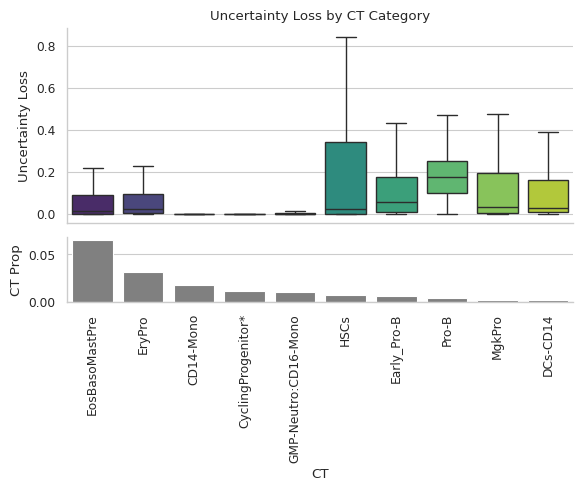

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="paper")

# Get unique ct_prop per ct
ct_prop_df = (
    annotated_df_concat[["ct", "real_ct_prop"]]
    .drop_duplicates()
)

# Sort cell types by proportion
ct_order = (
    ct_prop_df
    .sort_values("real_ct_prop", ascending=False)["ct"]
    .tolist()
)

# Create figure with different row heights
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(6,5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Boxplot (top)
sns.boxplot(
    data=annotated_df_concat,
    x="ct",
    y="uncertainty_loss",
    palette="viridis",
    showfliers=False,
    order=ct_order,
    ax=ax1
)

ax1.set_title("Uncertainty Loss by CT Category")
ax1.set_ylabel("Uncertainty Loss")
ax1.set_xlabel("")
sns.despine(ax=ax1)

# Barplot (bottom)
sns.barplot(
    data=ct_prop_df,
    x="ct",
    y="real_ct_prop",
    color="gray",
    order=ct_order,
    ax=ax2
)

ax2.set_ylabel("CT Prop")
ax2.set_xlabel("CT")
sns.despine(ax=ax2)

# Rotate labels
plt.xticks(rotation=90)

# Tight layout with small spacing
fig.subplots_adjust(hspace=0.15)
plt.tight_layout()

plt.show()

## Are the uncertain protocols different from the others 

In [106]:
# Read unique protocols
unique_protocols = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/unique_concentrations_adata.h5ad")

In [107]:
unique_protocols.obsm["X_original_scale"] = np.exp(unique_protocols.X) - 1

In [108]:
np.max(unique_protocols.X, axis=0)

array([2.39789527, 1.25276297, 6.62140565, 7.02197642, 7.02197642,
       3.93182563, 4.61512052, 3.25809654, 3.93182563, 3.04452244,
       3.04452244, 3.61091791])

In [109]:
np.max(unique_protocols.obsm["X_original_scale"], axis=0)

array([  10. ,    2.5,  750. , 1120. , 1120. ,   50. ,  100. ,   25. ,
         50. ,   20. ,   20. ,   36. ])

In [110]:
for cell_type, df in pure_cell_type_solution_dict_concat.items():
    # Subsample columns of generations 
    X_ct_generated = df.loc[:, protocol_cols].values
    
    C = np.mean(
        (np.log1p(X_ct_generated[:, None, :]) - unique_protocols.X[None, :, :])**2,
        axis=-1
    )

    min_dist = C.min(axis=1)
    mean_dist = C.mean(axis=1)
    max_dist = C.max(axis=1)

    # Save distances
    df.loc[:, "min_dist_from_real"] = min_dist
    df.loc[:, "mean_dist_from_real"] = mean_dist
    df.loc[:, "max_dist_from_real"] = max_dist

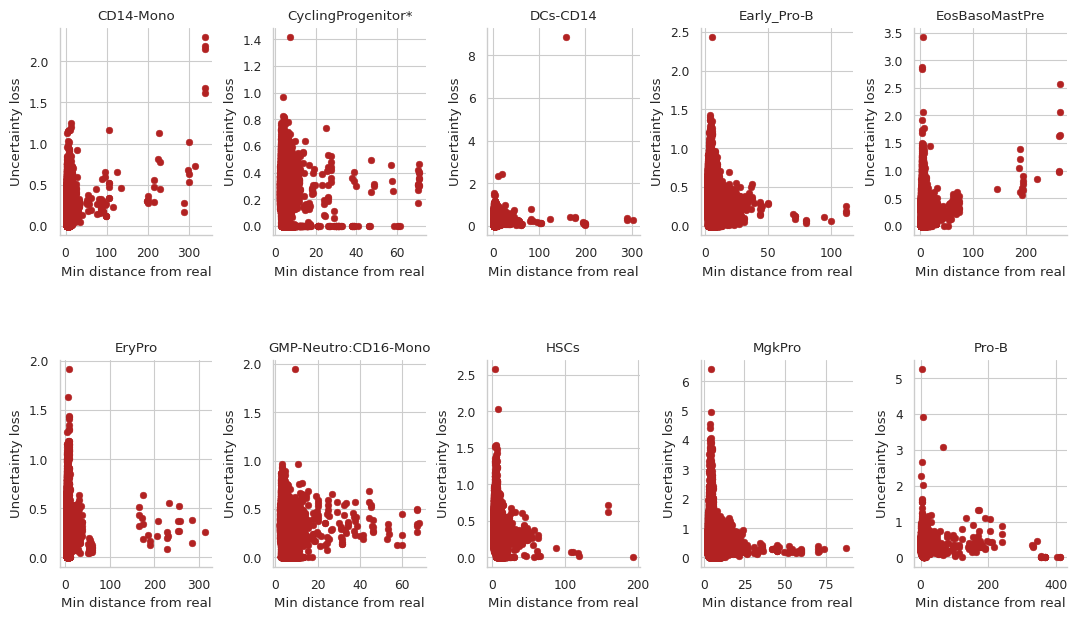

In [113]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13,7))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(pure_cell_type_solution_dict_concat):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x="mean_dist_from_real",
        y="target_ct_loss_std",
        ax=ax,
        edgecolor=None, 
        color="firebrick", 
    )

    # ax.set_yscale("log")   
    ax.set_title(cell_type)
    ax.set_xlabel("Min distance from real")
    ax.set_ylabel("Uncertainty loss")
    sns.despine(ax=ax)

# Check the various scores based on exploration-exploitation

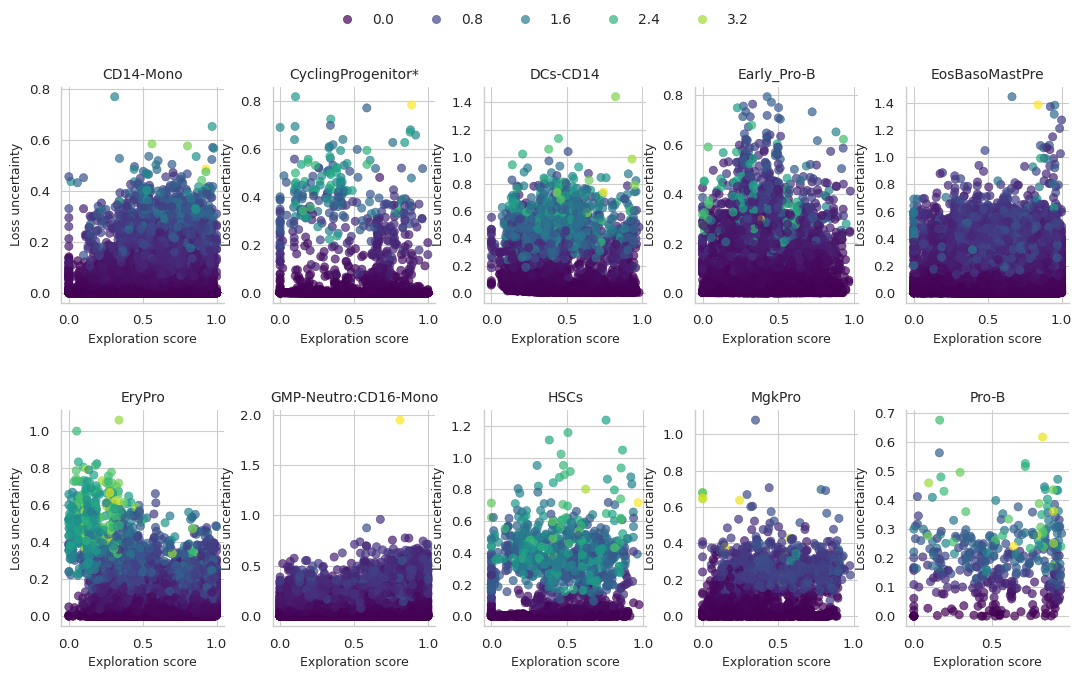

In [115]:
sns.set(style="whitegrid", context="paper", font_scale=1.1)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.3)  # slightly more compact spacing
axes = axes.flatten()

for i, cell_type in enumerate(annotated_df):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = annotated_df[cell_type].reset_index(drop=True)

    ax = axes[i]

    # scatter with hue, small and semi-transparent points
    sns.scatterplot(
        data=df_plot,
        x="exploration_score",
        y="uncertainty_loss",
        hue="target_ct_loss_mean",
        palette="viridis",
        s=35,
        alpha=0.7,
        ax=ax,
        edgecolor=None
    )

    ax.set_title(cell_type, fontsize=10)
    ax.set_xlabel("Exploration score", fontsize=9)
    ax.set_ylabel("Loss uncertainty", fontsize=9)
    ax.legend_.remove()  # remove individual legends to declutter
    sns.despine(ax=ax)

# Add a single legend for the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=10)

plt.show()

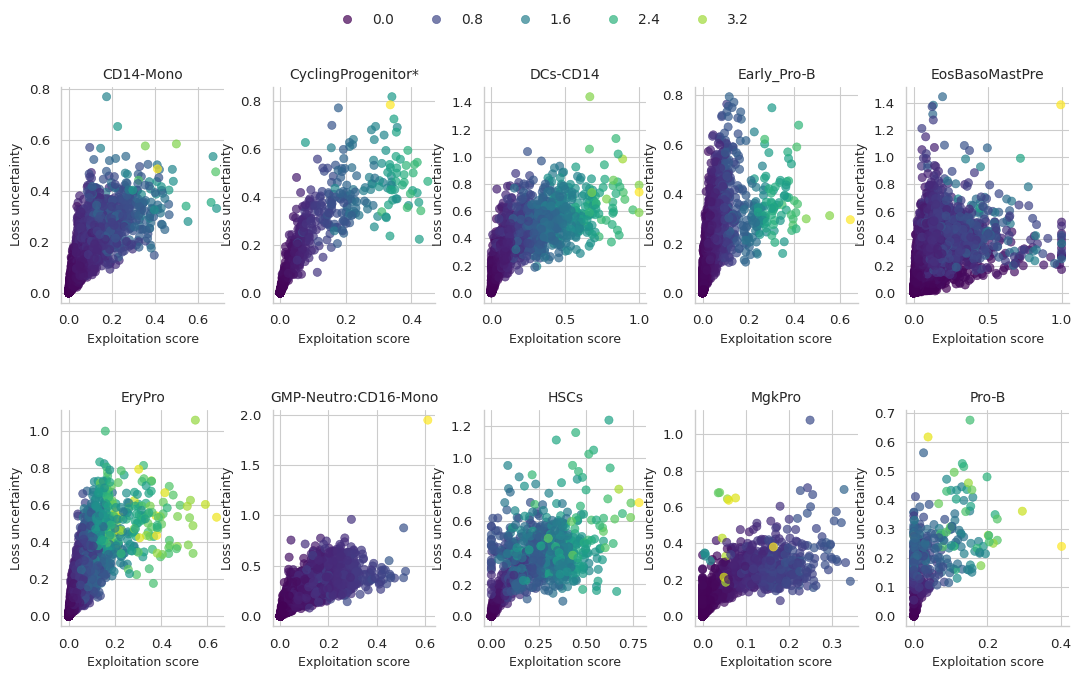

In [117]:
sns.set(style="whitegrid", context="paper", font_scale=1.1)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.3)  # slightly more compact spacing
axes = axes.flatten()

for i, cell_type in enumerate(annotated_df):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = annotated_df[cell_type].reset_index(drop=True)

    ax = axes[i]

    # scatter with hue, small and semi-transparent points
    sns.scatterplot(
        data=df_plot,
        x="exploitation_score",
        y="uncertainty_loss",
        hue="target_ct_loss_mean",
        palette="viridis",
        s=35,
        alpha=0.7,
        ax=ax,
        edgecolor=None
    )

    ax.set_title(cell_type, fontsize=10)
    ax.set_xlabel("Exploitation score", fontsize=9)
    ax.set_ylabel("Loss uncertainty", fontsize=9)
    ax.legend_.remove()  # remove individual legends to declutter
    sns.despine(ax=ax)

# Add a single legend for the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=10)

plt.show()

Weighted score 

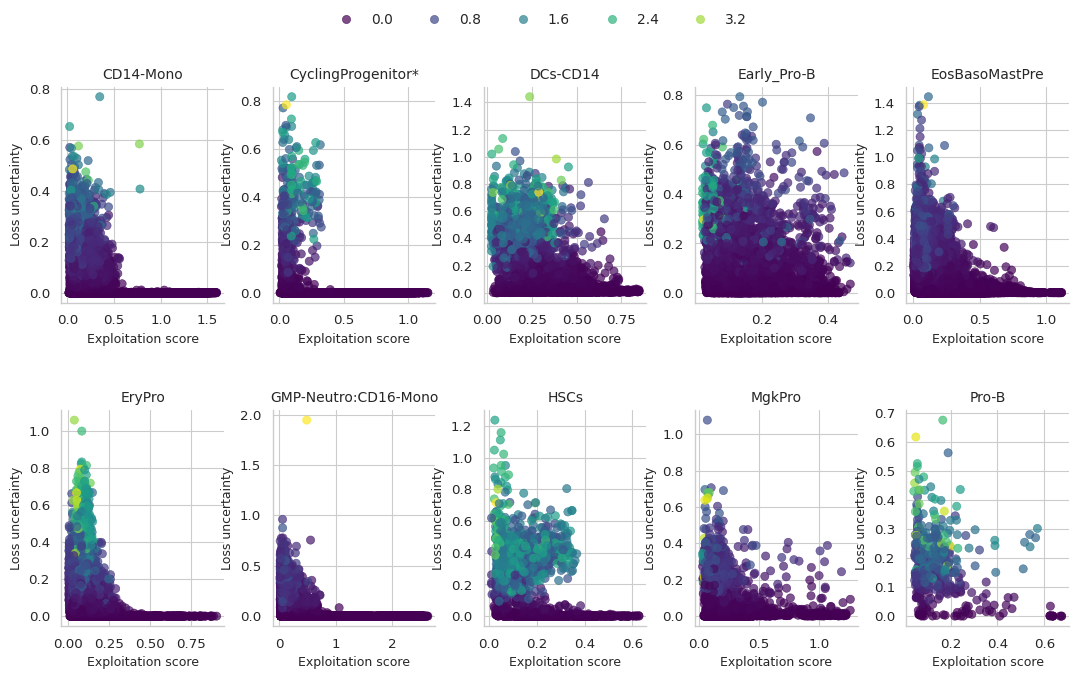

In [119]:
sns.set(style="whitegrid", context="paper", font_scale=1.1)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.3)  # slightly more compact spacing
axes = axes.flatten()

for i, cell_type in enumerate(annotated_df):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = annotated_df[cell_type].reset_index(drop=True)

    ax = axes[i]

    # scatter with hue, small and semi-transparent points
    sns.scatterplot(
        data=df_plot,
        x="weighted_uncertainty_score",
        y="uncertainty_loss",
        hue="target_ct_loss_mean",
        palette="viridis",
        s=35,
        alpha=0.7,
        ax=ax,
        edgecolor=None
    )

    ax.set_title(cell_type, fontsize=10)
    ax.set_xlabel("Exploitation score", fontsize=9)
    ax.set_ylabel("Loss uncertainty", fontsize=9)
    ax.legend_.remove()  # remove individual legends to declutter
    sns.despine(ax=ax)

# Add a single legend for the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=10)

plt.show()

Metric response surface

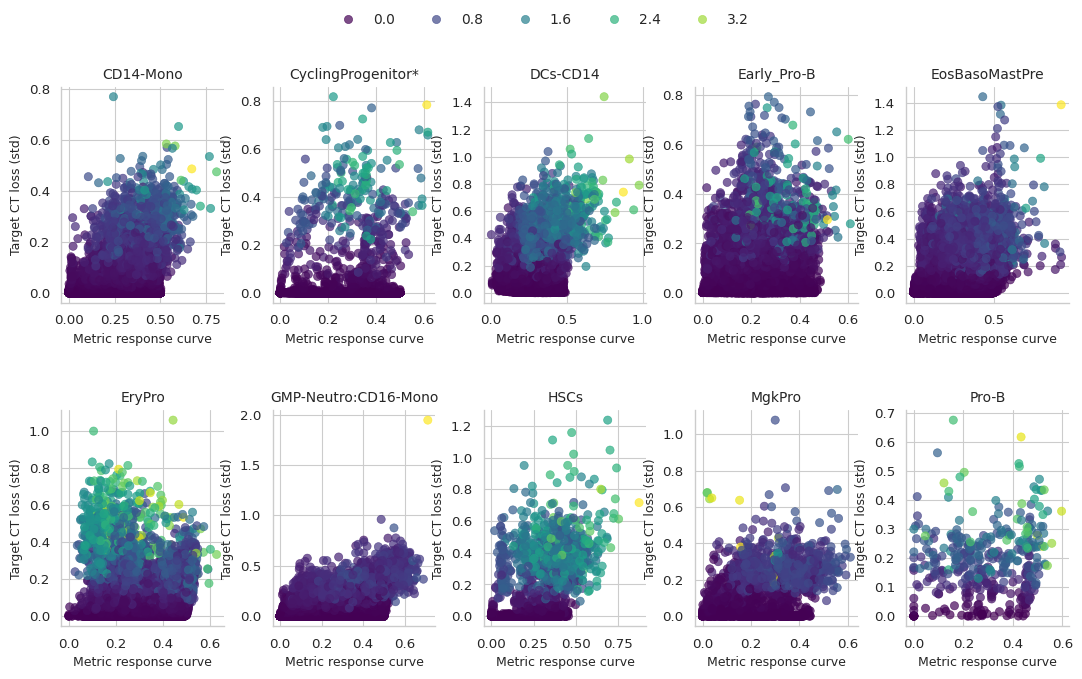

In [97]:
sns.set(style="whitegrid", context="paper", font_scale=1.1)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.3)  # slightly more compact spacing
axes = axes.flatten()

for i, cell_type in enumerate(annotated_df):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = annotated_df[cell_type].reset_index(drop=True)

    ax = axes[i]

    # scatter with hue, small and semi-transparent points
    sns.scatterplot(
        data=df_plot,
        x="metric_response_surface",
        y="uncertainty_loss",
        hue="target_ct_loss_mean",
        palette="viridis",
        s=35,
        alpha=0.7,
        ax=ax,
        edgecolor=None
    )

    ax.set_title(cell_type, fontsize=10)
    ax.set_xlabel("Metric response curve", fontsize=9)
    ax.set_ylabel("Target CT loss (std)", fontsize=9)
    ax.legend_.remove()  
    sns.despine(ax=ax)

# Add a single legend for the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=10)

plt.show()

## Check if the closest protocol to Sakurai is in the uncertainty pool 

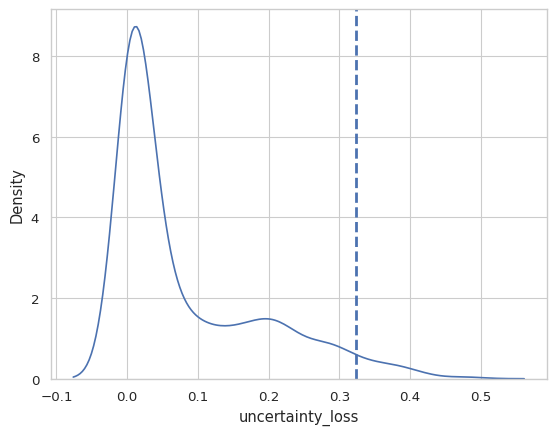

In [120]:
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

MgkPro_df = filtered_df["MgkPro"]
MgkPro_df = MgkPro_df.reset_index()

# dist_mgkpro_sakurai = np.abs(MgkPro_df.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)
dist_mgkpro_sakurai = np.abs(np.log1p(MgkPro_df.loc[:, protocol_cols].values) - np.log1p(sakurai_medium[None, :])).sum(1)

min_dist_sakurai = np.argmin(dist_mgkpro_sakurai)

sns.kdeplot(MgkPro_df, x="uncertainty_loss")
plt.axvline(MgkPro_df.iloc[min_dist_sakurai]["uncertainty_loss"], linestyle="--", linewidth=2)

In [99]:
MgkPro_df.iloc[min_dist_sakurai, :]

index                                                                      89
gm-csf_[ng_ml]                                                        2.59332
tpo_[ng_ml]                                                          0.092079
sr1_[nm]                                                             1.058537
um171_[nm]                                                           50.50305
um729_[µm]                                                                0.0
scf_[ng_ml]                                                               0.0
butyzamide_[nm]                                                     23.486666
retinoic_acid_[µm]                                                        0.0
ldl_[ng_ml]                                                               0.0
il3_[ng_ml]                                                         11.829242
o2_[%]                                                               17.98913
days_of_culture                                                 

In [121]:
MgkPro_df["MgkPro_prop"].max()

np.float64(0.61231595)

## Compare uncertainty of solutions that make the cut 

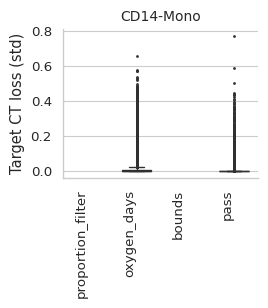

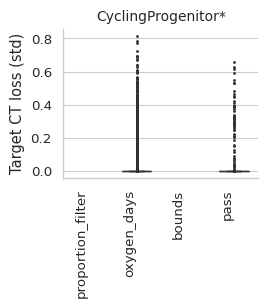

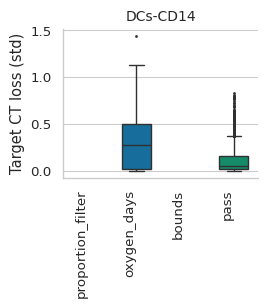

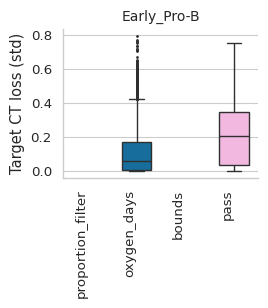

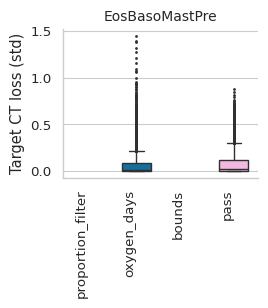

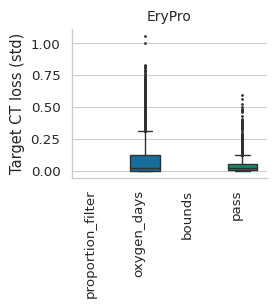

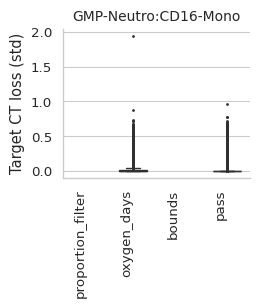

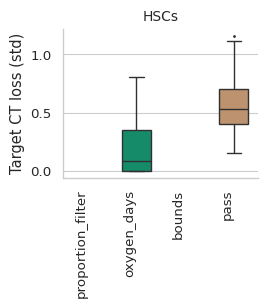

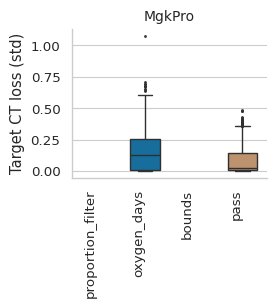

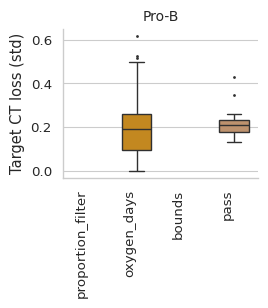

In [40]:
for cell_type in annotated_df:

    df_plot = annotated_df[cell_type].reset_index(drop=True)

    plt.figure(figsize=(2.8, 3.2))

    ax = sns.boxplot(
        data=df_plot,
        x="filtering_step",
        y="uncertainty_loss",
        hue="filtering_step", 
        order=["proportion_filter", "oxygen_days", "bounds", "pass"],
        width=0.6,
        fliersize=1,
        palette="colorblind"
    )

    # Clean aesthetics
    sns.despine()
    ax.set_xlabel("")
    ax.set_ylabel("Target CT loss (std)")
    ax.set_title(cell_type, fontsize=10)

    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.show()

## Plot uncertainties per molecule value

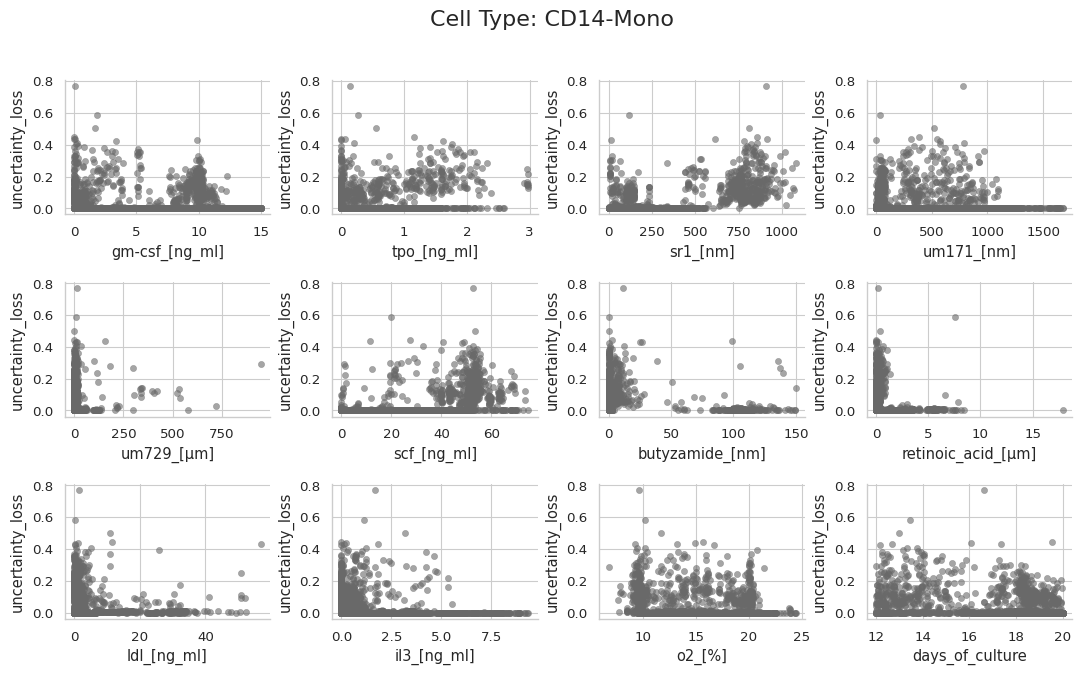

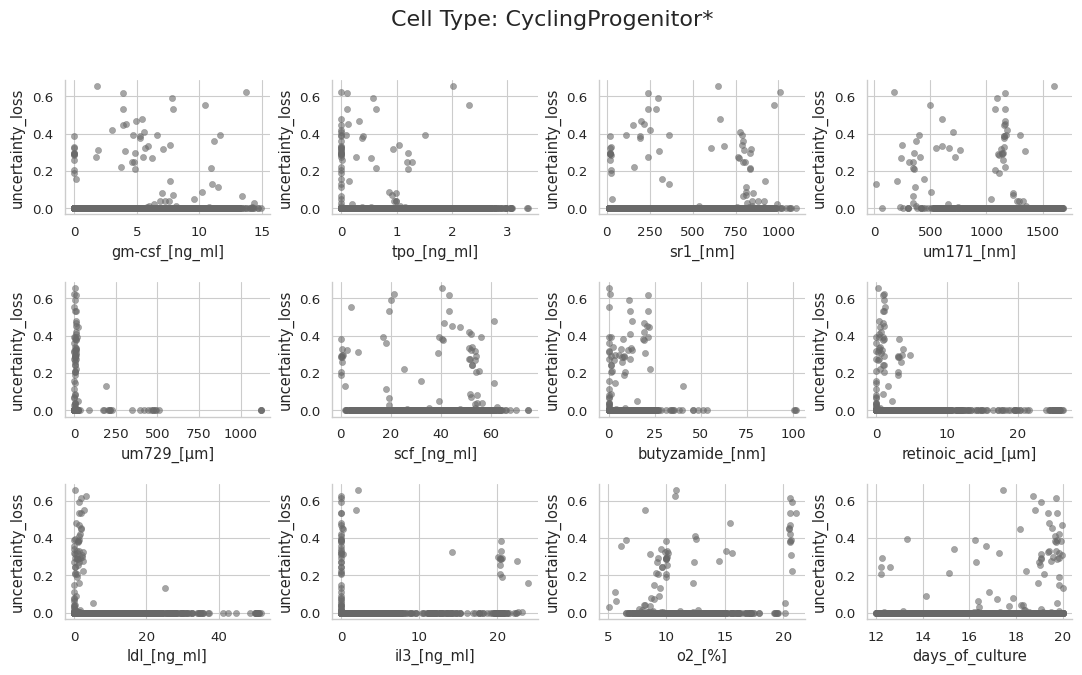

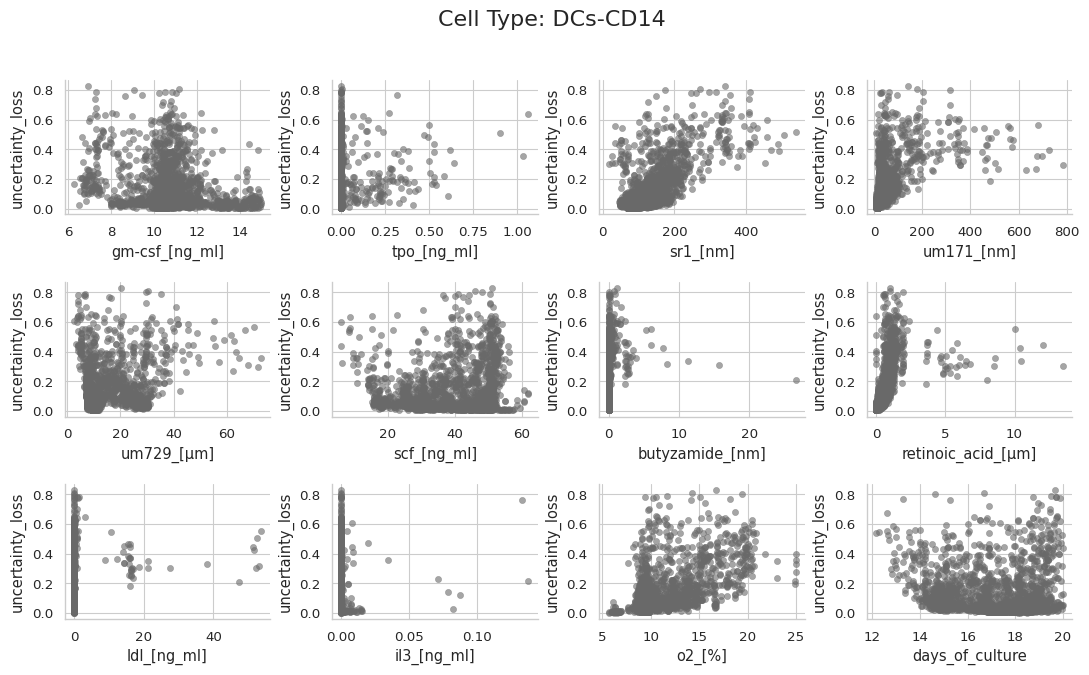

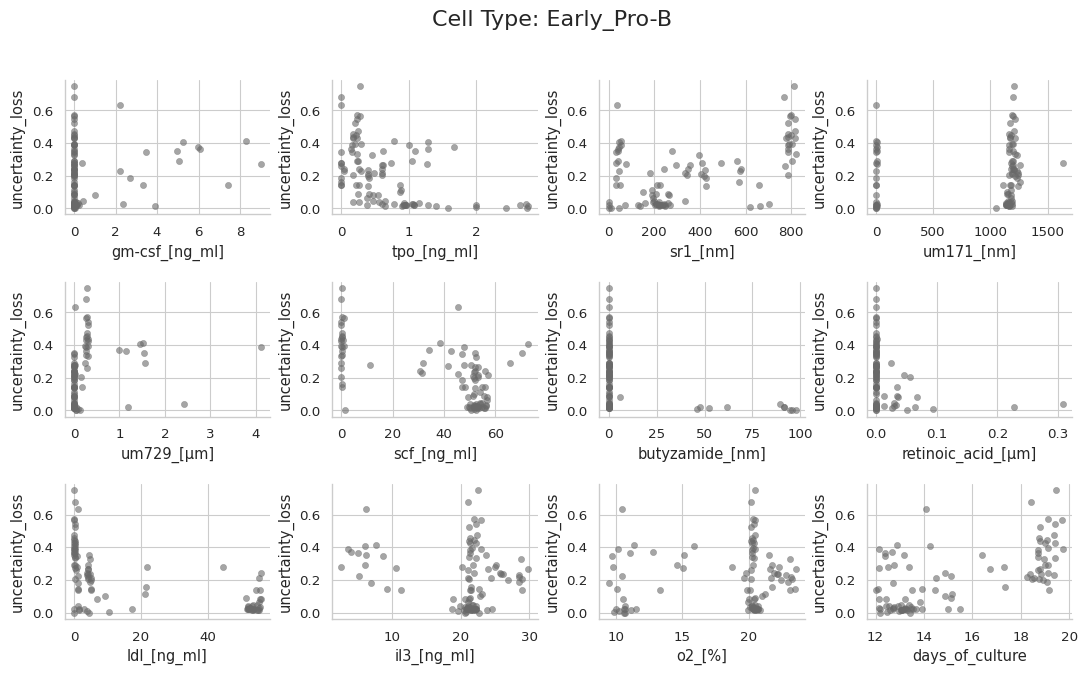

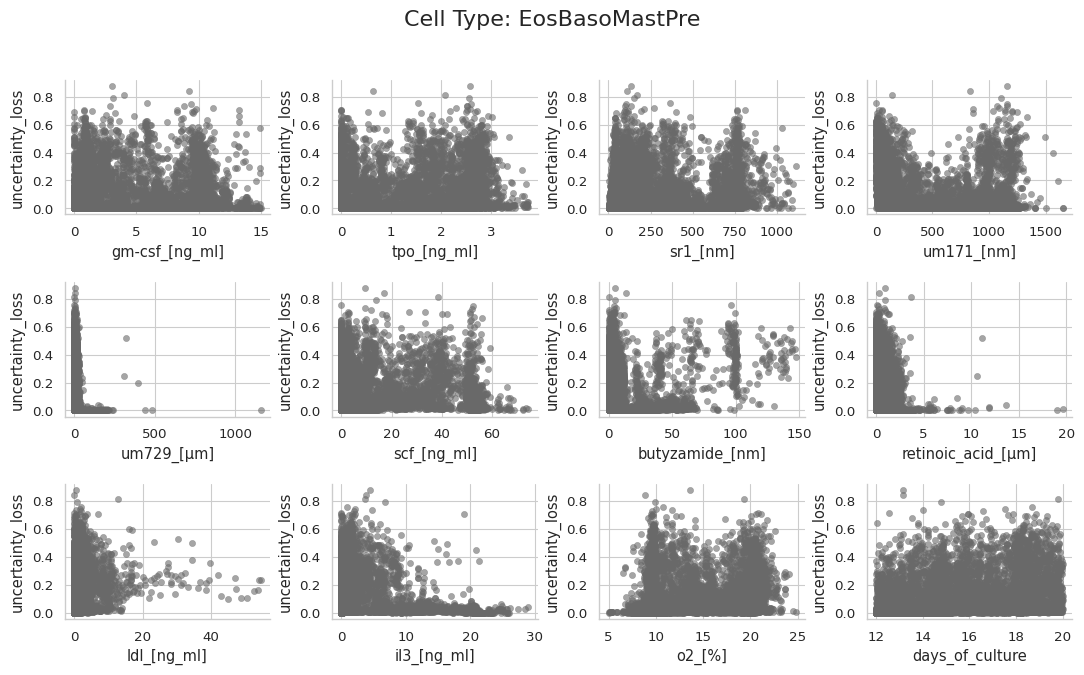

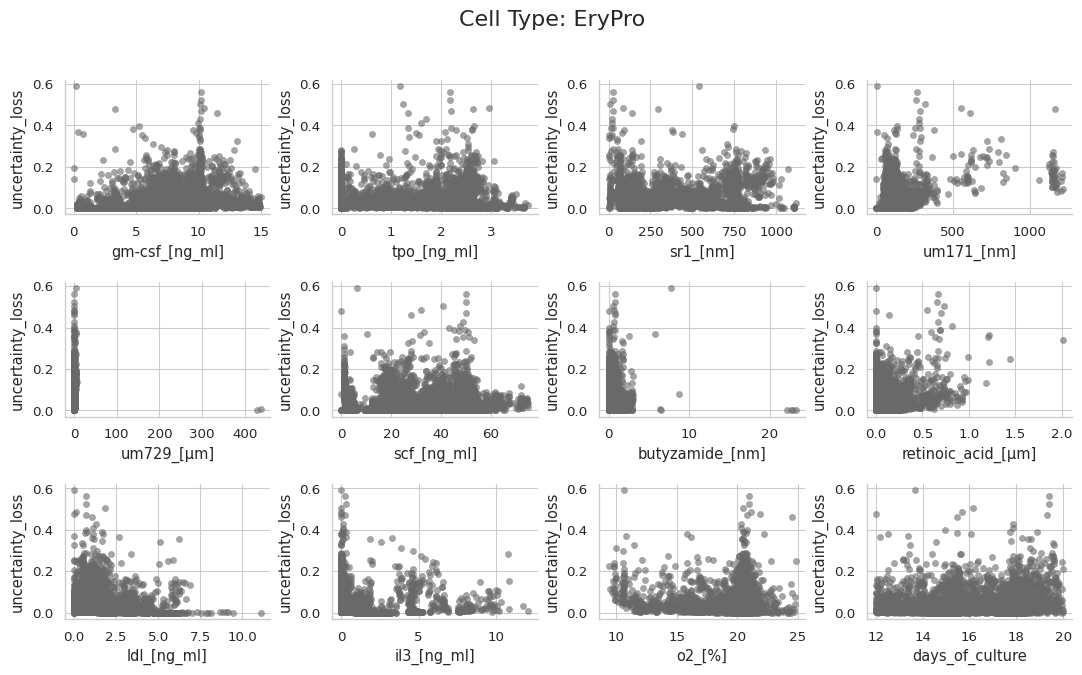

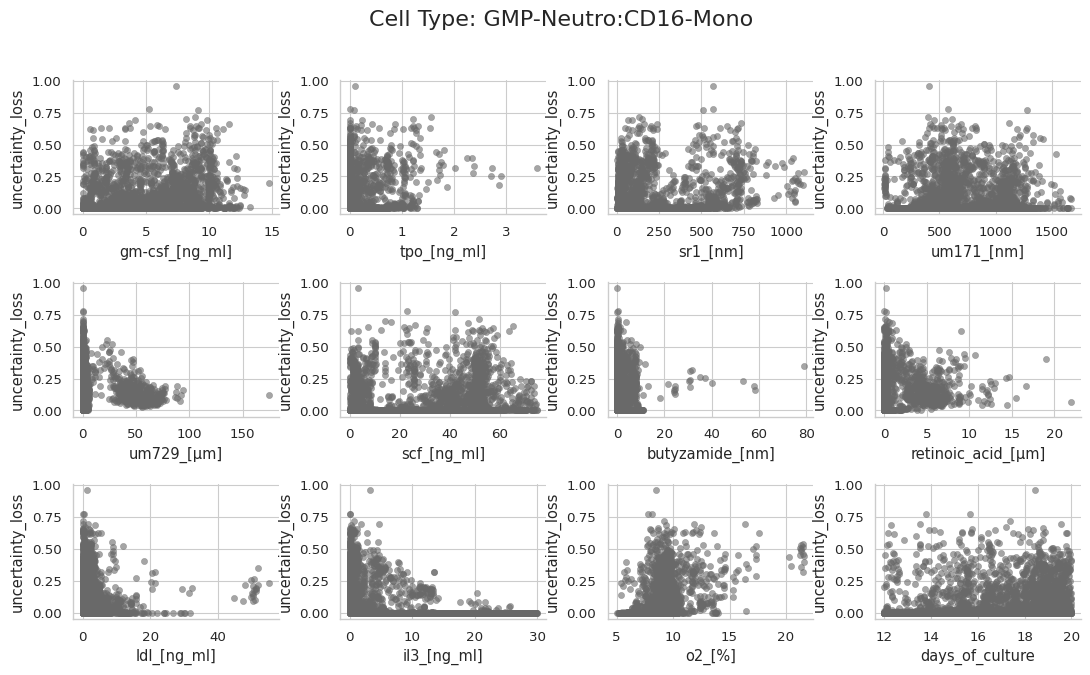

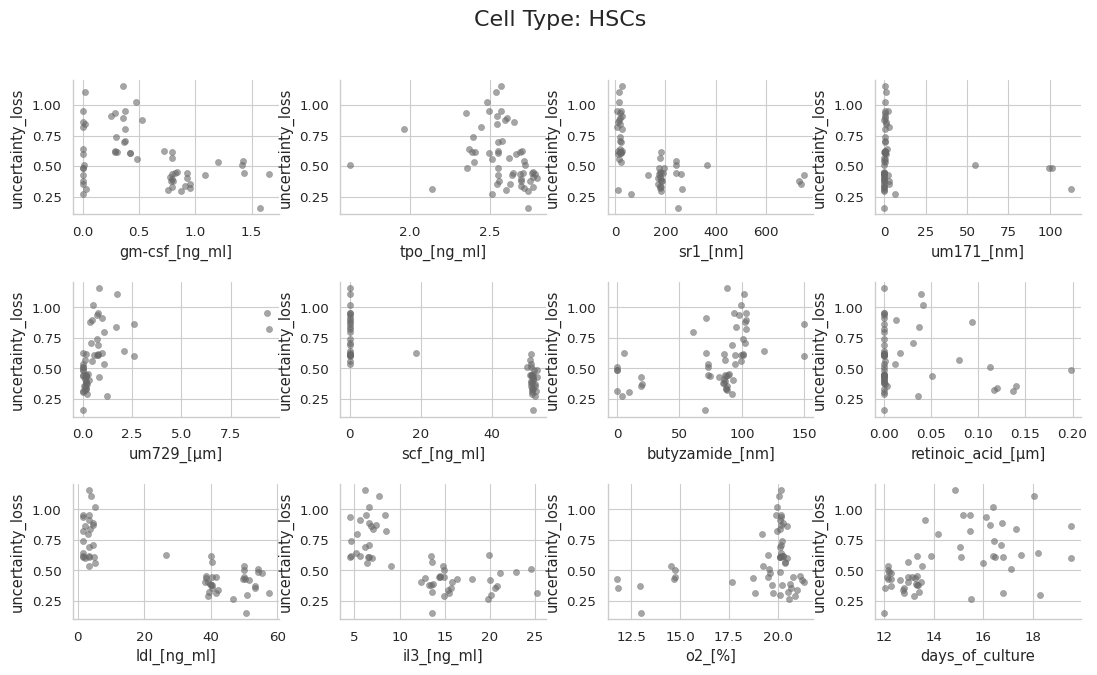

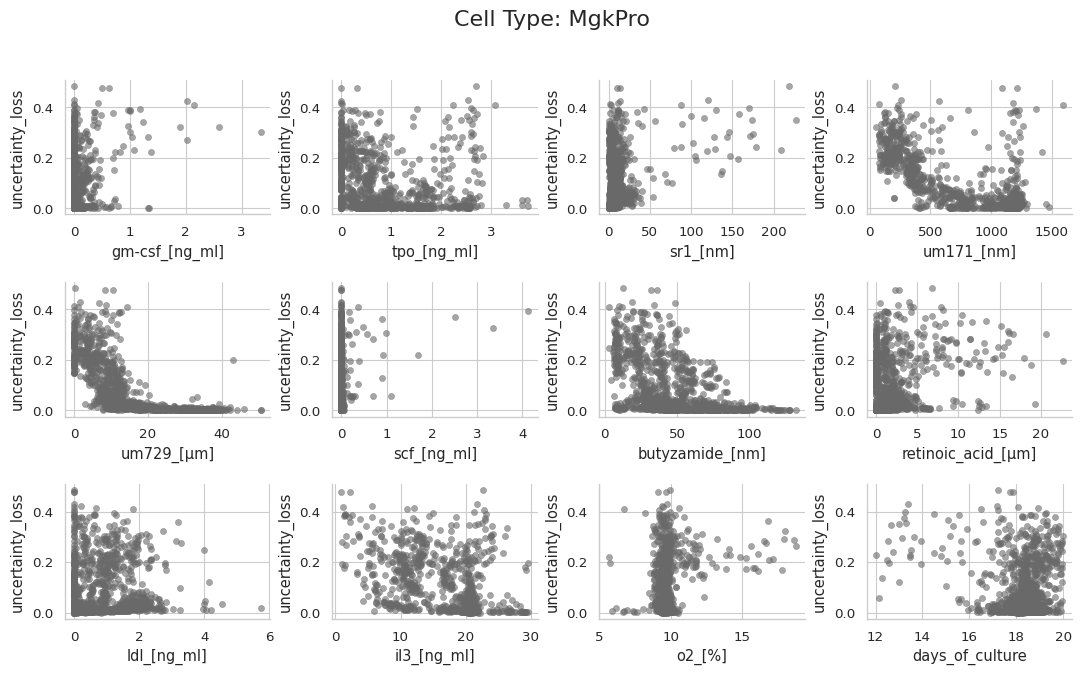

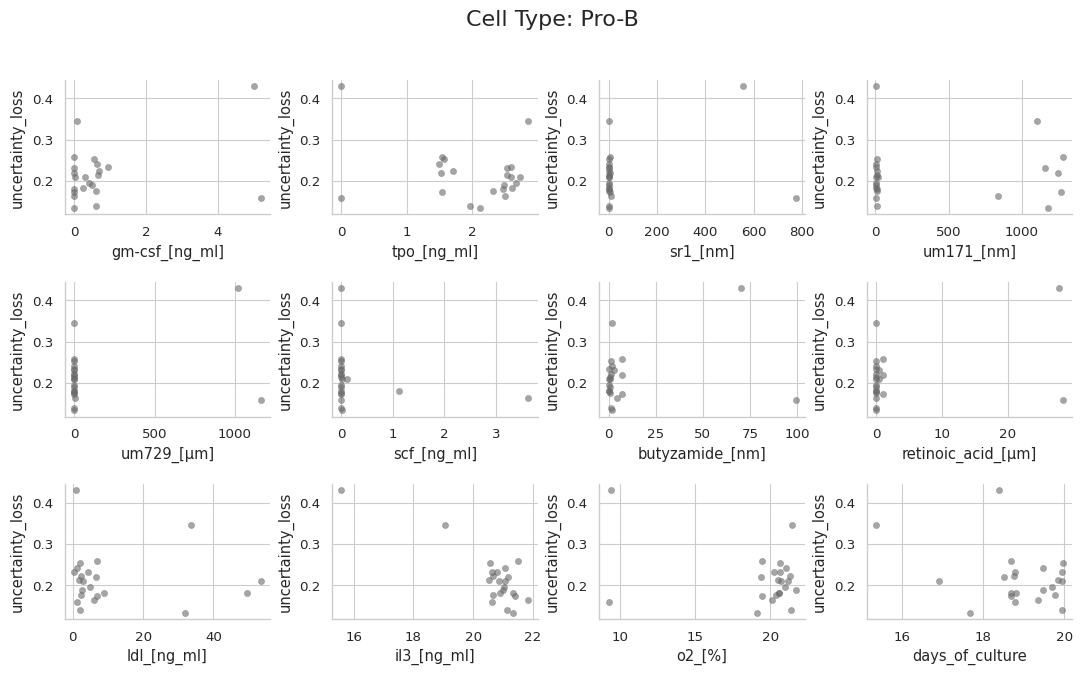

In [134]:
for cell_type in filtered_df:
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = filtered_df[cell_type].reset_index(drop=True)

    # Initialize the plots
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(13, 7))
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    axes = axes.flatten()

    # Add title based on cell type
    fig.suptitle(f"Cell Type: {cell_type}", fontsize=16)

    for i, protocol in enumerate(protocol_cols):
        ax = axes[i]
        sns.scatterplot(
            data=df_plot,
            x=protocol,
            y="uncertainty_loss",
            color="dimgray",
            legend=False,
            ax=ax,
            s=20,
            alpha=0.6,
            edgecolor=None
        )

        sns.despine(ax=ax)

    plt.show()